# Nusantara Script Classifier Classical ML

Klasifikasi aksara Bali/Jawa/Sunda.


# Setup Environment & Import Library & Path

In [ ]:
# SETUP ENVIRONMENT FOR KAGGLE, COLAB, CLOUD GPU, OR LOCAL

# run nya harus pake gpu klo ga bakal lama dan butuk proses ngambil gambar lambat
import os, sys, subprocess, importlib
from pathlib import Path

IS_KAGGLE = os.path.exists('/kaggle/input/datasets/fadhlannurrachman/script-aksara')
IS_COLAB  = 'google.colab' in sys.modules
IS_VASTAI = not IS_KAGGLE and not IS_COLAB

try:
    _r = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        capture_output=True, text=True, timeout=5
    )
    GPU_AVAILABLE = _r.returncode == 0 and bool(_r.stdout.strip())
    GPU_INFO = _r.stdout.strip().split('\n')[0] if GPU_AVAILABLE else 'tidak ada GPU'
except Exception:
    GPU_AVAILABLE = False
    GPU_INFO = 'tidak ada GPU'

print(f"Runtime : {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'vast.ai / lokal'}")
print(f"GPU     : {GPU_INFO}")
print(f"Python  : {sys.version.split()[0]}")

PKGS = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'pillow': 'PIL',
    'opencv-python-headless': 'cv2',
    'scikit-image': 'skimage',
    'scikit-learn': 'sklearn',
    'joblib': 'joblib',
    'tqdm': 'tqdm',
    'ipywidgets': 'ipywidgets',
    'optuna': 'optuna',
    'xgboost': 'xgboost',
    'lightgbm': 'lightgbm',
    'catboost': 'catboost',
    'streamlit': 'streamlit',
}

missing = []
for pkg, mod in PKGS.items():
    try:
        importlib.import_module(mod)
    except Exception:
        missing.append(pkg)

if missing:
    print('Install package yang belum ada:', missing)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)
else:
    print('Semua package utama sudah tersedia.')

print('Environment siap — pure classical ML, no CNN/deep learning training.')


Runtime : Kaggle
GPU     : Tesla T4, 15360 MiB
Python  : 3.12.12
Semua package utama sudah tersedia.
Environment siap — pure classical ML, no CNN/deep learning training.


In [ ]:
import os, zipfile, shutil
from pathlib import Path

if IS_KAGGLE:
    WORK_ROOT  = Path('/kaggle/working')
    INPUT_ROOT = Path('/kaggle/input')
    OUTPUT_DIR = WORK_ROOT / 'aksara_output_improved'
elif IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORK_ROOT  = Path('/content')
    INPUT_ROOT = Path('/content/drive/MyDrive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/aksara_output_improved')
else:
    WORK_ROOT  = Path.cwd()
    INPUT_ROOT = Path.cwd()
    OUTPUT_DIR = WORK_ROOT / 'aksara_output_improved'

FEATURES_DIR = OUTPUT_DIR / 'features'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)


def has_script_folders(p: Path):
    if not p.exists() or not p.is_dir():
        return False
    names = {x.name.lower() for x in p.iterdir() if x.is_dir()}
    return {'bali', 'jawa', 'sunda'}.issubset(names)


def find_dataset_root(search_roots, max_depth=8):
    checked = set()
    common_names = [
        'script_aksara', 'script-aksara', 'script aksara',
        'aksara', 'datasets', 'dataset', 'fadhlannurrachman',
    ]

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        root = root.resolve()
        if root in checked:
            continue
        checked.add(root)

        if has_script_folders(root):
            return root

        for name in common_names:
            c = root / name
            if has_script_folders(c):
                return c
            
        for d in root.rglob('*'):
            if not d.is_dir():
                continue
            try:
                rel_depth = len(d.relative_to(root).parts)
            except Exception:
                rel_depth = 99
            if rel_depth > max_depth:
                continue
            if has_script_folders(d):
                return d
    return None


def list_input_tree(base: Path, max_items=80):
    print('\nPreview /kaggle/input:')
    count = 0
    if not base.exists():
        print('  input root tidak ada:', base)
        return
    for p in sorted(base.rglob('*')):
        try:
            rel = p.relative_to(base)
        except Exception:
            rel = p
        if len(rel.parts) > 4:
            continue
        tag = '[DIR] ' if p.is_dir() else '[FILE]'
        print(' ', tag, rel)
        count += 1
        if count >= max_items:
            print('  ...')
            break

SEARCH_ROOTS = [INPUT_ROOT, WORK_ROOT, Path.cwd()]
DATASET_ROOT = find_dataset_root(SEARCH_ROOTS)

if DATASET_ROOT is None and INPUT_ROOT.exists():
    for archive in list(INPUT_ROOT.rglob('*.zip')) + list(INPUT_ROOT.rglob('*.tar')) + list(INPUT_ROOT.rglob('*.tar.gz')):
        try:
            extract_dir = WORK_ROOT / 'auto_extracted_dataset'
            extract_dir.mkdir(parents=True, exist_ok=True)
            if archive.suffix.lower() == '.zip' and not zipfile.is_zipfile(archive):
                print('Skip archive tidak valid:', archive)
                continue
            print('Fallback extract archive valid:', archive)
            shutil.unpack_archive(str(archive), str(extract_dir))
            DATASET_ROOT = find_dataset_root([extract_dir], max_depth=8)
            if DATASET_ROOT is not None:
                break
        except Exception as e:
            print('Skip archive gagal:', archive, '|', repr(e))

if DATASET_ROOT is None:
    list_input_tree(INPUT_ROOT)
    raise RuntimeError(
        'Dataset tidak ditemukan.\n'
    )

print('=' * 72)
print('PATH CHECK')
print('=' * 72)
print(f'WORK_ROOT    : {WORK_ROOT}')
print(f'INPUT_ROOT   : {INPUT_ROOT}')
print(f'DATASET_ROOT : {DATASET_ROOT}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')
print(f'FEATURES_DIR : {FEATURES_DIR}')
print(f'Dataset ada? : {DATASET_ROOT.exists()}')

print('\nIsi DATASET_ROOT:')
for p in sorted(DATASET_ROOT.iterdir()):
    print('  [DIR] ' if p.is_dir() else '  [FILE]', p.name)


PATH CHECK
WORK_ROOT    : /kaggle/working
INPUT_ROOT   : /kaggle/input
DATASET_ROOT : /kaggle/input/datasets/fadhlannurrachman/script-aksara
OUTPUT_DIR   : /kaggle/working/aksara_output_improved
FEATURES_DIR : /kaggle/working/aksara_output_improved/features
Dataset ada? : True

Isi DATASET_ROOT:
  [DIR]  Bali
  [DIR]  Jawa
  [DIR]  Sunda


In [ ]:
import time, warnings, gc
from math import pi
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import joblib
import optuna
from PIL import Image

from skimage.feature import hog, local_binary_pattern
from skimage.morphology import skeletonize
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RUN_PRESET = 'kaggle_t4x2_balance'

PRESETS = {
    'smoke_test': {
        'N_TRIALS': 5,
        'TUNE_FRAC': 0.20,
        'PCA_VARIANCE': 0.95,
        'AUG_TARGET_PER_CLASS': 200,
        'TUNING_TIMEOUT_SECONDS': 900,
        'AUG_MAX_EXTRA_PER_IMAGE': 2,
        'RUN_SVC': False,
        'RUN_TWO_STAGE': True,
        'EST_RUNTIME': '± 30–90 menit di Kaggle T4 x2',
    },
    'kaggle_t4x2_fast': {
        'N_TRIALS': 8,
        'TUNE_FRAC': 0.30,
        'PCA_VARIANCE': 0.98,
        'AUG_TARGET_PER_CLASS': 250,
        'TUNING_TIMEOUT_SECONDS': 1800,
        'AUG_MAX_EXTRA_PER_IMAGE': 3,
        'RUN_SVC': False,
        'RUN_TWO_STAGE': True,
        'EST_RUNTIME': '± 1–2.5 jam di Kaggle T4 x2',
    },
    'kaggle_t4x2_balance': {
        'N_TRIALS': 10,
        'TUNE_FRAC': 0.35,
        'PCA_VARIANCE': 0.98,
        'AUG_TARGET_PER_CLASS': 250,
        'TUNING_TIMEOUT_SECONDS': 1800,
        'AUG_MAX_EXTRA_PER_IMAGE': 3,
        'RUN_SVC': False,
        'RUN_TWO_STAGE': True,
        'EST_RUNTIME': '± 1.5–3 jam di Kaggle T4 x2',
    },
    'full_quality': {
        'N_TRIALS': 25,
        'TUNE_FRAC': 0.50,
        'PCA_VARIANCE': 0.98,
        'AUG_TARGET_PER_CLASS': 350,
        'TUNING_TIMEOUT_SECONDS': 3600,
        'AUG_MAX_EXTRA_PER_IMAGE': 3,
        'RUN_SVC': False,
        'RUN_TWO_STAGE': True,
        'EST_RUNTIME': '± 3–6 jam di Kaggle T4 x2',
    },
}

if RUN_PRESET not in PRESETS:
    raise ValueError(f'RUN_PRESET tidak valid: {RUN_PRESET}. Pilih salah satu: {list(PRESETS)}')

_cfg = PRESETS[RUN_PRESET]

RANDOM_STATE  = 42
IMG_SIZE      = 96  
TEST_SIZE     = 0.20
MAX_PER_CLASS = 350

PCA_VARIANCE  = float(_cfg['PCA_VARIANCE'])
N_TRIALS      = int(_cfg['N_TRIALS'])
TUNE_FRAC     = float(_cfg['TUNE_FRAC'])
TUNING_TIMEOUT_SECONDS = int(_cfg['TUNING_TIMEOUT_SECONDS'])

DROP_RARE_CLASSES = False
MIN_SAMPLES_PER_CLASS = 20

AUGMENT_TRAIN = True
AUG_TARGET_PER_CLASS = int(_cfg['AUG_TARGET_PER_CLASS'])
AUG_MAX_EXTRA_PER_IMAGE = int(_cfg['AUG_MAX_EXTRA_PER_IMAGE'])

RUN_SVC = bool(_cfg['RUN_SVC'])
RUN_TWO_STAGE = bool(_cfg['RUN_TWO_STAGE'])

FEATURE_VERSION = (
    f'v5_{RUN_PRESET}_img{IMG_SIZE}_pca{int(PCA_VARIANCE*100)}'
    f'_aug{AUG_TARGET_PER_CLASS}_stroke_guarded_final'
)

np.random.seed(RANDOM_STATE)

print('=' * 72)
print('AKSARA IMPROVED CLASSICAL ML CONFIG')
print('=' * 72)
print(f'RUN_PRESET            = {RUN_PRESET}')
print(f'Estimasi runtime      = {_cfg["EST_RUNTIME"]}')
print(f'IMG_SIZE              = {IMG_SIZE}px')
print(f'MAX_PER_CLASS         = {MAX_PER_CLASS}')
print(f'PCA_VARIANCE          = {PCA_VARIANCE}')
print(f'N_TRIALS              = {N_TRIALS}')
print(f'TUNE_FRAC             = {TUNE_FRAC}')
print(f'TUNING_TIMEOUT/model  = {TUNING_TIMEOUT_SECONDS//60} menit')
print(f'AUGMENT_TRAIN         = {AUGMENT_TRAIN}')
print(f'AUG_TARGET_PER_CLASS  = {AUG_TARGET_PER_CLASS}')
print(f'RUN_SVC               = {RUN_SVC}')
print(f'RUN_TWO_STAGE         = {RUN_TWO_STAGE}')
print(f'FEATURE_VERSION       = {FEATURE_VERSION}')
print()

XGBOOST_DEVICE  = 'cuda' if GPU_AVAILABLE else 'cpu'
LGBM_DEVICE     = 'cpu'
CATBOOST_DEVICE = 'GPU'  if GPU_AVAILABLE else 'CPU'

print(f'XGBoost device  : {XGBOOST_DEVICE}')
print(f'LightGBM device : {LGBM_DEVICE}')
print(f'CatBoost device : {CATBOOST_DEVICE}')
print()
print('Catatan: classical ML biasanya tidak pakai 2 GPU sekaligus. T4 x2 tetap membantu environment,')
print('tapi XGBoost/CatBoost umumnya hanya pakai 1 GPU. Jadi preset ini fokus hemat trial + timeout.')

AKSARA IMPROVED CLASSICAL ML CONFIG
RUN_PRESET            = kaggle_t4x2_balance
Estimasi runtime      = ± 1.5–3 jam di Kaggle T4 x2
IMG_SIZE              = 96px
MAX_PER_CLASS         = 350
PCA_VARIANCE          = 0.98
N_TRIALS              = 10
TUNE_FRAC             = 0.35
TUNING_TIMEOUT/model  = 30 menit
AUGMENT_TRAIN         = True
AUG_TARGET_PER_CLASS  = 250
RUN_SVC               = False
RUN_TWO_STAGE         = True
FEATURE_VERSION       = v5_kaggle_t4x2_balance_img96_pca98_aug250_stroke_guarded_final

XGBoost device  : cuda
LightGBM device : cpu
CatBoost device : GPU

Catatan: classical ML biasanya tidak pakai 2 GPU sekaligus. T4 x2 tetap membantu environment,
tapi XGBoost/CatBoost umumnya hanya pakai 1 GPU. Jadi preset ini fokus hemat trial + timeout.


In [4]:
# Quick runtime sanity check
print('Preset aktif:', RUN_PRESET)
print('Estimasi:', PRESETS[RUN_PRESET]['EST_RUNTIME'])
print('Timeout tuning per model:', TUNING_TIMEOUT_SECONDS, 'detik')
print('Total timeout tuning maksimum 3 model:', round((TUNING_TIMEOUT_SECONDS * 3) / 3600, 2), 'jam')
print('SVC aktif:', RUN_SVC, '| Two-stage aktif:', RUN_TWO_STAGE)

Preset aktif: kaggle_t4x2_balance
Estimasi: ± 1.5–3 jam di Kaggle T4 x2
Timeout tuning per model: 1800 detik
Total timeout tuning maksimum 3 model: 1.5 jam
SVC aktif: False | Two-stage aktif: True


# Load Dataset (Bali, Jawa, Sunda)

In [ ]:
import re as _re
from pathlib import Path

def _is_digit_class(name):
    s = name.strip().lower()

    if s.isdigit():
        return True

    if _re.match(r'^(angka|number|digit|num)[\s_\-]?\d+', s):
        return True

    if any(key in s for key in ['angka', 'number', 'digit', 'num']):
        return True

    return False


def _has_any_part(path, names):
    parts = [part.lower() for part in path.parts]
    names = [name.lower() for name in names]
    return any(name in parts for name in names)


SCRIPT_CONFIG = {
    'Bali': {
        'hints': ['Bali', 'bali'],
        'include_parts': ['letter'],
        'exclude_parts': ['number', 'numbers', 'angka', 'digit', 'digits']
    },
    'Jawa': {
        'hints': ['Jawa', 'jawa', 'Java', 'java'],
        'include_parts': ['all_class'],
        'exclude_parts': ['number', 'numbers', 'angka', 'digit', 'digits']
    },
    'Sunda': {
        'hints': ['Sunda', 'sunda', 'Sundanese'],
        'include_parts': ['consonant', 'vowel'],
        'exclude_parts': ['number', 'numbers', 'angka', 'digit', 'digits']
    }
}

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

records = []
rng = np.random.RandomState(RANDOM_STATE)

print(f'Mencari gambar di: {DATASET_ROOT}')
print()

for script_name, cfg in SCRIPT_CONFIG.items():
    found_imgs = []

    script_roots = []
    for d in DATASET_ROOT.rglob('*'):
        if d.is_dir() and any(d.name.lower() == hint.lower() for hint in cfg['hints']):
            script_roots.append(d)

    script_roots = list(set(script_roots))

    if not script_roots:
        print(f'[X] {script_name}: folder script tidak ditemukan')
        continue

    for root in script_roots:
        for p in root.rglob('*'):
            if not p.is_file():
                continue

            if p.suffix.lower() not in IMG_EXTS:
                continue

            if cfg['include_parts']:
                if not _has_any_part(p, cfg['include_parts']):
                    continue

            if _has_any_part(p, cfg['exclude_parts']):
                continue

            found_imgs.append(p)

    found_imgs = list(set(found_imgs))

    if not found_imgs:
        print(f'[X] {script_name}: tidak ada gambar huruf ditemukan')
        continue

    class_dict = {}

    for p in found_imgs:
        char_name = p.parent.name

        if _is_digit_class(char_name):
            continue

        class_dict.setdefault(char_name, []).append(p)

    total_sampled = 0

    for char_name, imgs in class_dict.items():
        if len(imgs) > MAX_PER_CLASS:
            imgs = list(rng.choice(imgs, MAX_PER_CLASS, replace=False))

        total_sampled += len(imgs)

        for p in imgs:
            records.append({
                'filepath': str(p),
                'script': script_name,
                'character': char_name,
                'label': f'{script_name}_{char_name}',
            })

    letter_classes = len(class_dict)

    print(
        f'[OK] {script_name}: {letter_classes} kelas huruf, '
        f'{total_sampled} gambar (cap={MAX_PER_CLASS}/kelas)'
    )

df = pd.DataFrame(records)

print()

if df.empty:
    raise RuntimeError('Dataset kosong! Cek path di sel konfigurasi.')

print(f'Total samples : {len(df):,}')
print(f'Total kelas   : {df["label"].nunique()}')
print()

print(df.groupby('script').agg(
    kelas=('label', 'nunique'),
    gambar=('filepath', 'count')
))
_class_counts = df['label'].value_counts().sort_values()
_rare = _class_counts[_class_counts < MIN_SAMPLES_PER_CLASS]

print()
print(f'Class di bawah {MIN_SAMPLES_PER_CLASS} samples: {len(_rare)}')
if len(_rare):
    print(_rare.head(20))

if DROP_RARE_CLASSES and len(_rare):
    before_n = len(df)
    before_c = df['label'].nunique()
    valid_labels = _class_counts[_class_counts >= MIN_SAMPLES_PER_CLASS].index
    df = df[df['label'].isin(valid_labels)].reset_index(drop=True)
    print(f'[FILTER] Drop rare class aktif: {before_c}->{df["label"].nunique()} kelas, {before_n}->{len(df)} samples')
else:
    print('DROP_RARE_CLASSES=False, semua kelas tetap dipakai.')

# Exploratory Data Analysis

In [ ]:
COLORS = {'Bali': '#E07B54', 'Jawa': '#5B8DB8', 'Sunda': '#57A773'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Sample per Script (setelah smart downsampling)', fontsize=13, fontweight='bold')

for ax, script in zip(axes, sorted(df['script'].unique())):
    counts = (
        df[df['script'] == script]
        .groupby('label')['filepath']
        .count()
        .sort_values(ascending=False)
    )
    ax.bar(range(len(counts)), counts.values,
           color=COLORS.get(script, '#888'), edgecolor='white', linewidth=0.3)
    ax.axhline(MAX_PER_CLASS, color='red', linestyle='--', linewidth=1, alpha=0.7,
               label=f'cap={MAX_PER_CLASS}')
    sub_df = df[df['script'] == script]
    ax.set_title(f'{script}  ({len(sub_df):,} samples, {counts.shape[0]} kelas)', fontweight='bold')
    ax.set_xlabel('Kelas Karakter')
    ax.set_ylabel('Jumlah')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUTPUT_DIR}/eda_distribution.png')

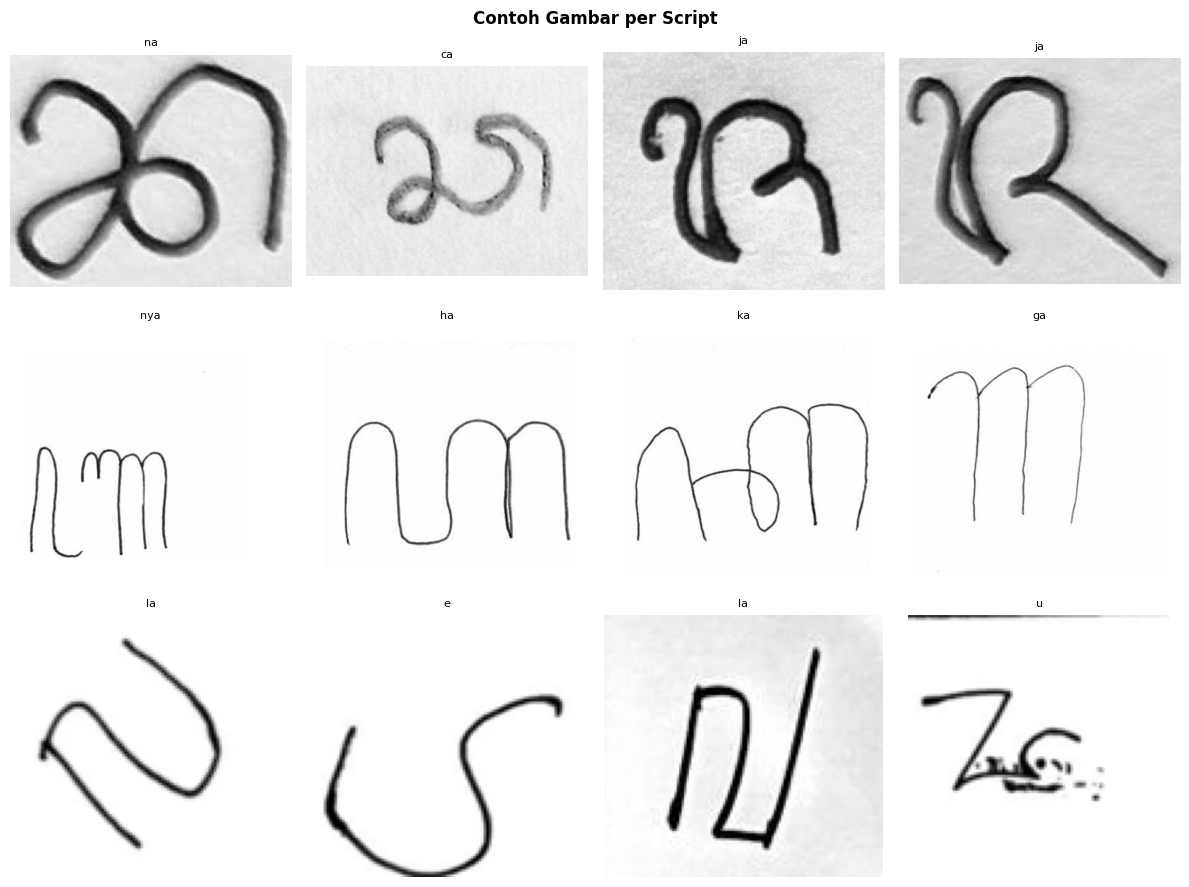

In [7]:
scripts_sorted = sorted(df['script'].unique())
fig, axes = plt.subplots(len(scripts_sorted), 4, figsize=(12, len(scripts_sorted) * 3))
fig.suptitle('Contoh Gambar per Script', fontsize=12, fontweight='bold')

for row, script in enumerate(scripts_sorted):
    sub = df[df['script'] == script].sample(min(4, len(df[df['script'] == script])),
                                             random_state=RANDOM_STATE)
    for col, (_, r) in enumerate(sub.iterrows()):
        ax = axes[row][col]
        try:
            img = np.array(Image.open(r['filepath']).convert('L'))
            ax.imshow(img, cmap='gray')
        except Exception:
            ax.text(0.5, 0.5, '?', ha='center', va='center')
        ax.set_title(r['character'], fontsize=8)
        ax.axis('off')
    axes[row][0].set_ylabel(script, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# Image Preprocessing Pipeline

Pipeline : grayscale → optional train augmentation → CLAHE/denoise → Otsu auto-invert → morphology cleanup → crop bounding box → square padding → center by mass → resize.

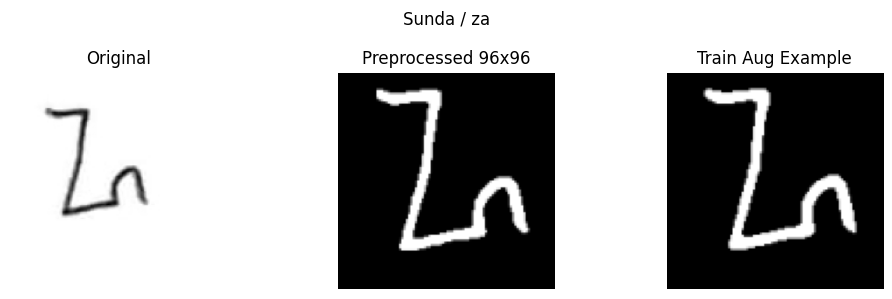

Shape: (96, 96)  dtype: uint8  foreground ratio: 0.116


In [ ]:
def _augment_gray(arr: np.ndarray, variant: int = 0, seed: int = 42) -> np.ndarray:
    if variant == 0:
        return arr

    rng = np.random.RandomState(seed + variant * 1009)
    h, w = arr.shape[:2]

    # Rotate kecil + translate kecil. Jangan terlalu ekstrim karena aksara sensitif.
    angle = rng.uniform(-8, 8)
    scale = rng.uniform(0.92, 1.08)
    tx = rng.uniform(-0.06, 0.06) * w
    ty = rng.uniform(-0.06, 0.06) * h

    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[:, 2] += [tx, ty]
    aug = cv2.warpAffine(
        arr, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )

    # Brightness/contrast ringan
    alpha = rng.uniform(0.90, 1.12)
    beta = rng.uniform(-10, 10)
    aug = np.clip(alpha * aug + beta, 0, 255).astype(np.uint8)

    # Blur/noise ringan
    if rng.rand() < 0.35:
        aug = cv2.GaussianBlur(aug, (3, 3), 0)
    if rng.rand() < 0.25:
        noise = rng.normal(0, 4, size=aug.shape)
        aug = np.clip(aug.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return aug


def _auto_binary_foreground(gray: np.ndarray) -> np.ndarray:
    gray = gray.astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(gray)
    g = cv2.fastNlMeansDenoising(g, None, h=8, templateWindowSize=7, searchWindowSize=21)
    g = cv2.GaussianBlur(g, (3, 3), 0)

    # Otsu dua arah, lalu pilih yang foreground ratio-nya masuk akal.
    _, b_inv = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    _, b     = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    candidates = []
    for cand in [b_inv, b]:
        ratio = (cand > 0).mean()
        # ideal stroke biasanya tidak memenuhi seluruh canvas
        penalty = abs(ratio - 0.18)
        if ratio < 0.01 or ratio > 0.80:
            penalty += 10
        candidates.append((penalty, cand))

    binary = min(candidates, key=lambda x: x[0])[1]

    # Morphology ringan: close stroke putus, open noise kecil.
    k2 = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k2, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  k2, iterations=1)

    return binary.astype(np.uint8)


def _crop_pad_center(binary: np.ndarray, out_size: int = IMG_SIZE, pad_ratio: float = 0.18) -> np.ndarray:
    ys, xs = np.where(binary > 0)
    if len(xs) == 0 or len(ys) == 0:
        return cv2.resize(binary, (out_size, out_size), interpolation=cv2.INTER_AREA)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    crop = binary[y1:y2+1, x1:x2+1]

    h, w = crop.shape
    side = max(h, w)
    pad = int(side * pad_ratio)
    canvas_size = side + 2 * pad
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    yoff = (canvas_size - h) // 2
    xoff = (canvas_size - w) // 2
    canvas[yoff:yoff+h, xoff:xoff+w] = crop

    # Centering by mass supaya stroke tidak terlalu geser.
    m = cv2.moments(canvas)
    if m['m00'] > 0:
        cx = int(m['m10'] / m['m00'])
        cy = int(m['m01'] / m['m00'])
        shift_x = canvas_size // 2 - cx
        shift_y = canvas_size // 2 - cy
        M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        canvas = cv2.warpAffine(canvas, M, (canvas_size, canvas_size), borderValue=0)

    return cv2.resize(canvas, (out_size, out_size), interpolation=cv2.INTER_AREA).astype(np.uint8)


def preprocess_image(filepath: str, augment_variant: int = 0, seed: int = RANDOM_STATE) -> np.ndarray:
    with Image.open(filepath) as pil:
        arr = np.array(pil.convert('L'), dtype=np.uint8)

    arr = _augment_gray(arr, variant=augment_variant, seed=seed)
    binary = _auto_binary_foreground(arr)
    proc = _crop_pad_center(binary, out_size=IMG_SIZE)
    return proc


_demo = df.sample(1, random_state=0).iloc[0]
_orig = np.array(Image.open(_demo['filepath']).convert('L'))
_proc = preprocess_image(_demo['filepath'])
_proc_aug = preprocess_image(_demo['filepath'], augment_variant=1, seed=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(_orig, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(_proc, cmap='gray')
axes[1].set_title(f'Preprocessed {IMG_SIZE}x{IMG_SIZE}')
axes[1].axis('off')
axes[2].imshow(_proc_aug, cmap='gray')
axes[2].set_title('Train Aug Example')
axes[2].axis('off')
plt.suptitle(f'{_demo["script"]} / {_demo["character"]}')
plt.tight_layout()
plt.show()

print(f'Shape: {_proc.shape}  dtype: {_proc.dtype}  foreground ratio: {(_proc > 0).mean():.3f}')

# Feature Extraction

Fitur diperkuat untuk aksara:

| Deskriptor | Tujuan |
|---|---|
| HOG | orientasi stroke dan bentuk utama |
| LBP | tekstur lokal/mikro pattern |
| Gabor | filter orientasi multi-skala |
| Zoning multigrid | kepadatan stroke per area |
| Projection profile | distribusi stroke horizontal/vertical |
| Hu moments + contour | bentuk global, extent, solidity, perimeter |
| Skeleton features | endpoint, junction, stroke graph kasar |


In [9]:
def _build_gabor_kernels(freqs, thetas):
    kernels = []
    for freq in freqs:
        sigma = 0.4 / freq
        lambd = 1.0 / freq
        ks    = int(2 * np.ceil(3.0 * sigma) + 1)
        ks    = min(ks | 1, 63)
        for theta in thetas:
            kr = cv2.getGaborKernel((ks, ks), sigma, theta, lambd, 0.5, 0,       cv2.CV_32F)
            ki = cv2.getGaborKernel((ks, ks), sigma, theta, lambd, 0.5, pi / 2,  cv2.CV_32F)
            kernels.append((kr, ki))
    return kernels


class FeatureExtractor:
    GABOR_FREQS  = [0.08, 0.14, 0.22, 0.32]
    GABOR_THETAS = [0, pi/8, pi/4, 3*pi/8, pi/2, 5*pi/8, 3*pi/4, 7*pi/8]

    def __init__(self):
        self._gabor_kernels = _build_gabor_kernels(self.GABOR_FREQS, self.GABOR_THETAS)

    def _fg(self, img):
        return (img > 0).astype(np.uint8)

    def hog(self, img):
        return hog(
            img,
            orientations=12,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True,
        ).astype(np.float32)

    def lbp(self, img):
        pattern = local_binary_pattern(img, P=24, R=3, method='uniform')
        hist, _ = np.histogram(pattern.ravel(), bins=26, range=(0, 26), density=True)
        return hist.astype(np.float32)

    def gabor(self, img):
        img_f = img.astype(np.float32) / 255.0
        n     = len(self._gabor_kernels)
        feats = np.empty(n * 4, dtype=np.float32)
        for i, (kr, ki) in enumerate(self._gabor_kernels):
            real = cv2.filter2D(img_f, cv2.CV_32F, kr)
            imag = cv2.filter2D(img_f, cv2.CV_32F, ki)
            mag  = np.sqrt(real * real + imag * imag)
            b = i * 4
            feats[b], feats[b+1] = mag.mean(), mag.std()
            feats[b+2], feats[b+3] = np.percentile(mag, 75), np.percentile(mag, 90)
        return feats

    def zoning(self, img):
        fg = self._fg(img).astype(np.float32)
        feats = []

        # Multi-grid density: 4x4 dan 8x8
        for grid in [4, 8]:
            cell = IMG_SIZE // grid
            crop = fg[:grid*cell, :grid*cell]
            zones = crop.reshape(grid, cell, grid, cell).transpose(0, 2, 1, 3).reshape(grid * grid, cell * cell)
            feats.extend(zones.mean(axis=1))
            feats.extend(zones.std(axis=1))

        # Projection profile full + downsampled
        h = fg.sum(axis=1)
        v = fg.sum(axis=0)
        h = h / (h.max() + 1e-8)
        v = v / (v.max() + 1e-8)
        feats.extend(h)
        feats.extend(v)

        for bins in [8, 16]:
            h_bins = h.reshape(bins, IMG_SIZE // bins).mean(axis=1)
            v_bins = v.reshape(bins, IMG_SIZE // bins).mean(axis=1)
            feats.extend(h_bins)
            feats.extend(v_bins)

        return np.asarray(feats, dtype=np.float32)

    def shape_features(self, img):
        fg = self._fg(img)
        feats = []

        area = float(fg.sum())
        total = float(fg.size)
        feats.append(area / (total + 1e-8))

        # Moments / Hu moments
        moments = cv2.moments((fg * 255).astype(np.uint8))
        hu = cv2.HuMoments(moments).flatten()
        hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
        feats.extend(hu)

        # Contour features
        contours, _ = cv2.findContours((fg * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cnt = max(contours, key=cv2.contourArea)
            c_area = float(cv2.contourArea(cnt))
            perim = float(cv2.arcLength(cnt, True))
            x, y, w, h = cv2.boundingRect(cnt)
            hull = cv2.convexHull(cnt)
            hull_area = float(cv2.contourArea(hull))
            aspect = w / (h + 1e-8)
            extent = c_area / (w * h + 1e-8)
            solidity = c_area / (hull_area + 1e-8)
            circularity = 4 * np.pi * c_area / (perim * perim + 1e-8)
            feats.extend([c_area / total, perim / (IMG_SIZE * 4), aspect, extent, solidity, circularity])
        else:
            feats.extend([0, 0, 0, 0, 0, 0])

        # Connected components
        num_labels, labels, stats, cent = cv2.connectedComponentsWithStats(fg.astype(np.uint8), connectivity=8)
        comp_count = max(0, num_labels - 1)
        comp_areas = stats[1:, cv2.CC_STAT_AREA] if comp_count else np.array([0])
        feats.extend([
            comp_count / 10.0,
            float(comp_areas.max()) / (area + 1e-8),
            float(comp_areas.mean()) / (area + 1e-8),
        ])

        # Skeleton graph kasar
        try:
            skel = skeletonize(fg > 0).astype(np.uint8)
            skel_count = float(skel.sum())
            kernel = np.ones((3, 3), dtype=np.uint8)
            neigh = cv2.filter2D(skel, -1, kernel) - skel
            endpoints = int(((skel == 1) & (neigh == 1)).sum())
            junctions  = int(((skel == 1) & (neigh >= 3)).sum())
            feats.extend([skel_count / (area + 1e-8), endpoints / 20.0, junctions / 20.0])
        except Exception:
            feats.extend([0, 0, 0])

        return np.asarray(feats, dtype=np.float32)

    def extract(self, img):
        return np.concatenate([
            self.hog(img),
            self.lbp(img),
            self.gabor(img),
            self.zoning(img),
            self.shape_features(img),
        ]).astype(np.float32)


_dummy = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
_dummy[20:44, 24:40] = 255
_ext   = FeatureExtractor()
_fv    = _ext.extract(_dummy)
print(f'HOG      : {_ext.hog(_dummy).shape[0]:>5d}')
print(f'LBP      : {_ext.lbp(_dummy).shape[0]:>5d}')
print(f'Gabor    : {_ext.gabor(_dummy).shape[0]:>5d}')
print(f'Zoning   : {_ext.zoning(_dummy).shape[0]:>5d}')
print(f'Shape    : {_ext.shape_features(_dummy).shape[0]:>5d}')
print(f'TOTAL    : {_fv.shape[0]:>5d}')

HOG      :  5808
LBP      :    26
Gabor    :   128
Zoning   :   400
Shape    :    20
TOTAL    :  6382


# Label Encoding & Stratified Split

In [ ]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

joblib.dump(le, OUTPUT_DIR / 'label_encoder.pkl')
np.save(str(OUTPUT_DIR / 'class_names.npy'), CLASS_NAMES)

X_paths_train_full, X_paths_test, y_train_full, y_test = train_test_split(
    df['filepath'].values,
    df['label_enc'].values,
    test_size=TEST_SIZE,
    stratify=df['label_enc'].values,
    random_state=RANDOM_STATE,
)

try:
    X_paths_train, X_paths_val, y_train, y_val = train_test_split(
        X_paths_train_full,
        y_train_full,
        test_size=0.15,
        stratify=y_train_full,
        random_state=RANDOM_STATE,
    )
except ValueError as e:
    print('Warning: internal validation stratify gagal, fallback non-stratified:', e)
    X_paths_train, X_paths_val, y_train, y_val = train_test_split(
        X_paths_train_full,
        y_train_full,
        test_size=0.15,
        stratify=None,
        random_state=RANDOM_STATE,
    )

print(f'Kelas               : {N_CLASSES}')
print(f'Train base samples  : {len(y_train):,}  (akan di-augment khusus train)')
print(f'Validation samples  : {len(y_val):,}  (tanpa augmentasi)')
print(f'Test samples        : {len(y_test):,}  (tanpa augmentasi)')
print(f'Label range         : {y_train.min()} – {y_train.max()}')

Kelas               : 64
Train base samples  : 13,603  (akan di-augment khusus train)
Validation samples  : 2,401  (tanpa augmentasi)
Test samples        : 4,001  (tanpa augmentasi)
Label range         : 0 – 63


# Ekstraksi Fitur

In [ ]:
_worker_ext = None

def _worker_init():
    global _worker_ext
    _worker_ext = FeatureExtractor()


def _worker_extract(job):
    fp, lbl, aug_variant, seed = job
    try:
        img  = preprocess_image(str(fp), augment_variant=int(aug_variant), seed=int(seed))
        feat = _worker_ext.extract(img)
        return feat, int(lbl)
    except Exception as e:
        return None


def _make_jobs(filepaths, labels, augment=False):
    filepaths = np.asarray(filepaths)
    labels = np.asarray(labels)
    jobs = []

    for i, (fp, lbl) in enumerate(zip(filepaths, labels)):
        jobs.append((str(fp), int(lbl), 0, RANDOM_STATE + i))

    if not augment or not AUGMENT_TRAIN:
        return jobs

    counts = pd.Series(labels).value_counts().to_dict()
    rng = np.random.RandomState(RANDOM_STATE)

    extra_jobs = []
    for cls, n in counts.items():
        need = max(0, min(AUG_TARGET_PER_CLASS, MAX_PER_CLASS) - int(n))
        if need <= 0:
            continue

        idxs = np.where(labels == cls)[0]
        rng.shuffle(idxs)

        made = 0
        loop = 0
        while made < need and loop < AUG_MAX_EXTRA_PER_IMAGE:
            for idx in idxs:
                if made >= need:
                    break
                variant = loop + 1
                extra_jobs.append((str(filepaths[idx]), int(labels[idx]), variant, RANDOM_STATE + int(idx) + loop * 10000))
                made += 1
            loop += 1

    print(f'  Augment jobs tambahan: {len(extra_jobs):,}')
    return jobs + extra_jobs


def extract_batch(filepaths, labels, cache_path, augment=False):
    lbl_path = cache_path.with_name(cache_path.stem + '_labels.npy')
    meta_path = cache_path.with_suffix('.meta.txt')

    if cache_path.exists() and lbl_path.exists():
        print(f'  [cache] {cache_path.name}')
        return (np.load(str(cache_path)).astype(np.float32),
                np.load(str(lbl_path)).astype(np.int32))

    import multiprocessing
    n_workers = min(multiprocessing.cpu_count(), 8)
    jobs = _make_jobs(filepaths, labels, augment=augment)

    print(f'  Ekstrak {len(jobs):,} gambar/jobs ({n_workers} worker, augment={augment})...', flush=True)
    t0 = time.time()

    with ProcessPoolExecutor(max_workers=n_workers, initializer=_worker_init) as ex:
        results = list(ex.map(_worker_extract, jobs, chunksize=64))

    results = [r for r in results if r is not None]
    X = np.stack([r[0] for r in results]).astype(np.float32)
    y = np.array([r[1] for r in results], dtype=np.int32)
    print(f'  Selesai dalam {time.time()-t0:.1f}s  ->  shape {X.shape}')

    np.save(str(cache_path), X)
    np.save(str(lbl_path), y)
    with open(meta_path, 'w') as f:
        f.write(f'FEATURE_VERSION={FEATURE_VERSION}\n')
        f.write(f'augment={augment}\n')
        f.write(f'jobs={len(jobs)}\n')
        f.write(f'shape={X.shape}\n')

    return X, y


print('Mengekstrak fitur TRAIN base + augmentasi...')
X_train_raw, y_train = extract_batch(
    X_paths_train,
    y_train,
    FEATURES_DIR / f'train_raw_{FEATURE_VERSION}.npy',
    augment=True
)

print('Mengekstrak fitur VALIDATION internal tanpa augmentasi...')
X_val_raw, y_val = extract_batch(
    X_paths_val,
    y_val,
    FEATURES_DIR / f'val_raw_{FEATURE_VERSION}.npy',
    augment=False
)

print('Mengekstrak fitur TEST tanpa augmentasi...')
X_test_raw, y_test = extract_batch(
    X_paths_test,
    y_test,
    FEATURES_DIR / f'test_raw_{FEATURE_VERSION}.npy',
    augment=False
)

FEAT_DIM = X_train_raw.shape[1]
print(f'Feature matrix: train={X_train_raw.shape}  val={X_val_raw.shape}  test={X_test_raw.shape}')
print('Train label distribution setelah augmentasi:')
print(pd.Series(y_train).value_counts().describe())

Mengekstrak fitur TRAIN base + augmentasi...
  Augment jobs tambahan: 2,171
  Ekstrak 15,774 gambar/jobs (4 worker, augment=True)...
  Selesai dalam 951.1s  ->  shape (15774, 6382)
Mengekstrak fitur VALIDATION internal tanpa augmentasi...
  Ekstrak 2,401 gambar/jobs (4 worker, augment=False)...
  Selesai dalam 148.1s  ->  shape (2401, 6382)
Mengekstrak fitur TEST tanpa augmentasi...
  Ekstrak 4,001 gambar/jobs (4 worker, augment=False)...
  Selesai dalam 247.6s  ->  shape (4001, 6382)
Feature matrix: train=(15774, 6382)  val=(2401, 6382)  test=(4001, 6382)
Train label distribution setelah augmentasi:
count     64.00000
mean     246.46875
std       28.25000
min       24.00000
25%      250.00000
50%      250.00000
75%      250.00000
max      250.00000
Name: count, dtype: float64


# StandardScaler + PCA 

In [12]:
_tr_cache = FEATURES_DIR / f'train_pca_{FEATURE_VERSION}.npy'
_va_cache = FEATURES_DIR / f'val_pca_{FEATURE_VERSION}.npy'
_te_cache = FEATURES_DIR / f'test_pca_{FEATURE_VERSION}.npy'
_sc_pkl   = OUTPUT_DIR / f'scaler_{FEATURE_VERSION}.pkl'
_pca_pkl  = OUTPUT_DIR / f'pca_model_{FEATURE_VERSION}.pkl'

if _tr_cache.exists() and _va_cache.exists() and _te_cache.exists() and _sc_pkl.exists() and _pca_pkl.exists():
    print('[cache] Load PCA features...')
    X_train = np.load(str(_tr_cache)).astype(np.float32)
    X_val   = np.load(str(_va_cache)).astype(np.float32)
    X_test  = np.load(str(_te_cache)).astype(np.float32)
    scaler  = joblib.load(_sc_pkl)
    pca     = joblib.load(_pca_pkl)
else:
    print('Fitting StandardScaler...')
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train_raw)
    X_va_s = scaler.transform(X_val_raw)
    X_te_s = scaler.transform(X_test_raw)
    joblib.dump(scaler, _sc_pkl)

    print(f'Fitting PCA (target var={PCA_VARIANCE})...')
    t0  = time.time()
    pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE, svd_solver='full')
    X_train = pca.fit_transform(X_tr_s).astype(np.float32)
    X_val   = pca.transform(X_va_s).astype(np.float32)
    X_test  = pca.transform(X_te_s).astype(np.float32)
    joblib.dump(pca, _pca_pkl)
    print(f'  Selesai dalam {time.time()-t0:.1f}s')

    np.save(str(_tr_cache), X_train)
    np.save(str(_va_cache), X_val)
    np.save(str(_te_cache), X_test)

    del X_tr_s, X_va_s, X_te_s
    gc.collect()

# Simpan juga dengan nama generik untuk inference app compatibility
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
joblib.dump(pca, OUTPUT_DIR / 'pca_model.pkl')

PCA_DIM = X_train.shape[1]
print(f'  {FEAT_DIM}D  ->  {PCA_DIM}D  (reduksi {(1 - PCA_DIM/FEAT_DIM)*100:.0f}%)')
print(f'  Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Fitting StandardScaler...
Fitting PCA (target var=0.98)...
  Selesai dalam 78.3s
  6382D  ->  2479D  (reduksi 61%)
  Variance explained: 98.00%
  Train: (15774, 2479)  Val: (2401, 2479)  Test: (4001, 2479)


# Export Preview Feature Extraction ke CSV

Cell ini menyimpan contoh hasil feature extraction supaya bentuk datanya bisa dilihat di CSV.


In [ ]:
FEATURE_EXPORT_MAX_ROWS = 300

def _safe_class_name_from_id(label_id):
    label_id = int(label_id)
    if 0 <= label_id < len(CLASS_NAMES):
        return str(CLASS_NAMES[label_id])
    return str(label_id)


def build_feature_schema():
    ext = FeatureExtractor()
    dummy = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    dummy[20:44, 24:40] = 255

    blocks = [
        ('hog', ext.hog(dummy)),
        ('lbp', ext.lbp(dummy)),
        ('gabor', ext.gabor(dummy)),
        ('zoning_projection', ext.zoning(dummy)),
        ('shape_skeleton', ext.shape_features(dummy)),
    ]

    rows = []
    start = 0
    feature_types = []
    local_indices = []

    for name, arr in blocks:
        length = int(len(arr))
        end = start + length
        rows.append({
            'feature_block': name,
            'start_col': start,
            'end_col_exclusive': end,
            'n_features': length,
            'column_range': f'feat_{start:04d} ... feat_{end-1:04d}'
        })
        feature_types.extend([name] * length)
        local_indices.extend(list(range(length)))
        start = end

    schema_df = pd.DataFrame(rows)
    detail_df = pd.DataFrame({
        'feature_col': [f'feat_{i:04d}' for i in range(start)],
        'feature_block': feature_types,
        'local_index': local_indices,
    })

    return schema_df, detail_df


schema_df, feature_detail_df = build_feature_schema()
schema_path = OUTPUT_DIR / 'feature_block_schema.csv'
detail_path = OUTPUT_DIR / 'feature_column_detail.csv'
schema_df.to_csv(schema_path, index=False)
feature_detail_df.to_csv(detail_path, index=False)

print('Feature block schema:')
display(schema_df)
print(f'Saved: {schema_path}')
print(f'Saved: {detail_path}')

n_export = min(FEATURE_EXPORT_MAX_ROWS, len(y_test))

meta_df = pd.DataFrame({
    'split': ['test'] * n_export,
    'filepath': [str(p) for p in np.asarray(X_paths_test)[:n_export]],
    'label_id': np.asarray(y_test)[:n_export].astype(int),
})
meta_df['label'] = meta_df['label_id'].apply(_safe_class_name_from_id)
meta_df['script'] = meta_df['label'].astype(str).str.split('_').str[0]
meta_df['character'] = meta_df['label'].astype(str).str.split('_', n=1).str[1]

raw_feature_cols = [f'feat_{i:04d}' for i in range(X_test_raw.shape[1])]
raw_feature_df = pd.DataFrame(X_test_raw[:n_export], columns=raw_feature_cols)
raw_feature_export = pd.concat([meta_df, raw_feature_df], axis=1)
raw_feature_path = OUTPUT_DIR / 'feature_extraction_test_preview.csv'
raw_feature_export.to_csv(raw_feature_path, index=False)

print(f'Raw engineered feature preview saved: {raw_feature_path}')
print('Shape:', raw_feature_export.shape)
display(raw_feature_export.head())

pca_cols = [f'pca_{i:04d}' for i in range(X_test.shape[1])]
pca_feature_df = pd.DataFrame(X_test[:n_export], columns=pca_cols)
pca_feature_export = pd.concat([meta_df, pca_feature_df], axis=1)
pca_feature_path = OUTPUT_DIR / 'pca_features_test_preview.csv'
pca_feature_export.to_csv(pca_feature_path, index=False)

print(f'PCA feature preview saved: {pca_feature_path}')
print('Shape:', pca_feature_export.shape)
display(pca_feature_export.head())

pixels = []
for fp in np.asarray(X_paths_test)[:n_export]:
    img = preprocess_image(str(fp), augment_variant=0, seed=RANDOM_STATE)
    pixels.append((img.astype(np.float32) / 255.0).reshape(-1))

pixels = np.asarray(pixels, dtype=np.float32)
pixel_cols = [f'px_{i:04d}' for i in range(pixels.shape[1])]
pixel_df = pd.DataFrame(pixels, columns=pixel_cols)
pixel_export = pd.concat([meta_df, pixel_df], axis=1)
pixel_path = OUTPUT_DIR / 'preprocessed_pixels_test_preview.csv'
pixel_export.to_csv(pixel_path, index=False)

print(f'Preprocessed pixel preview saved: {pixel_path}')
print('Shape:', pixel_export.shape)
display(pixel_export.head())

Feature block schema:


,feature_block,start_col,end_col_exclusive,n_features,column_range
0,hog,0,5808,5808,feat_0000 ... feat_5807
1,lbp,5808,5834,26,feat_5808 ... feat_5833
2,gabor,5834,5962,128,feat_5834 ... feat_5961
3,zoning_projection,5962,6362,400,feat_5962 ... feat_6361
4,shape_skeleton,6362,6382,20,feat_6362 ... feat_6381


Saved: /kaggle/working/aksara_output_improved/feature_block_schema.csv
Saved: /kaggle/working/aksara_output_improved/feature_column_detail.csv
Raw engineered feature preview saved: /kaggle/working/aksara_output_improved/feature_extraction_test_preview.csv
Shape: (300, 6388)


,split,filepath,label_id,label,script,character,feat_0000,feat_0001,feat_0002,feat_0003,...,feat_6372,feat_6373,feat_6374,feat_6375,feat_6376,feat_6377,feat_6378,feat_6379,feat_6380,feat_6381
0,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,12,Bali_pa,Bali,pa,0.0,0.0,0.0,0.0,...,0.847222,0.453666,0.534612,0.091377,0.1,1.000000,1.0,0.139258,0.30,1.80
1,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,55,Sunda_sya,Sunda,sya,0.0,0.0,0.0,0.0,...,1.392157,0.308478,0.389810,0.076515,0.1,1.000000,1.0,0.226555,0.30,0.95
2,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,10,Bali_nga,Bali,nga,0.0,0.0,0.0,0.0,...,1.674419,0.232397,0.286653,0.046071,0.1,1.000000,1.0,0.202867,0.20,0.30
3,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,19,Jawa_ca,Jawa,ca,0.0,0.0,0.0,0.0,...,1.411765,0.119553,0.137834,0.019625,0.1,1.000000,1.0,0.431208,0.15,0.60
4,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,43,Sunda_ka,Sunda,ka,0.0,0.0,0.0,0.0,...,0.562500,0.272569,0.453102,0.195391,0.2,0.529112,0.5,0.120815,0.25,0.20


PCA feature preview saved: /kaggle/working/aksara_output_improved/pca_features_test_preview.csv
Shape: (300, 2485)


,split,filepath,label_id,label,script,character,pca_0000,pca_0001,pca_0002,pca_0003,...,pca_2469,pca_2470,pca_2471,pca_2472,pca_2473,pca_2474,pca_2475,pca_2476,pca_2477,pca_2478
0,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,12,Bali_pa,Bali,pa,22.718054,8.347799,18.733919,-14.970584,...,0.325300,-0.176997,0.771392,0.598935,0.203323,0.216468,-0.231624,0.428844,0.278474,0.242648
1,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,55,Sunda_sya,Sunda,sya,1.539420,-2.495726,6.904917,5.293538,...,-0.755446,0.308041,-0.122063,0.180052,-0.544403,-0.146347,0.041662,-0.182974,0.447720,-0.011909
2,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,10,Bali_nga,Bali,nga,-18.915689,-8.395005,0.094311,0.582101,...,0.079107,-0.237461,0.077497,0.687138,-0.293617,-0.008640,-0.290947,-0.023596,0.379707,-0.043297
3,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,19,Jawa_ca,Jawa,ca,-15.799578,14.783279,-13.026245,-1.936732,...,0.244709,0.328536,0.051462,0.249633,0.569336,0.043408,0.385672,-0.103274,0.142589,0.009741
4,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,43,Sunda_ka,Sunda,ka,1.916836,7.955977,8.368033,22.654181,...,0.046741,0.016693,-0.600420,0.024366,0.063081,-0.068685,0.148773,0.753305,-0.244583,-1.059131


Preprocessed pixel preview saved: /kaggle/working/aksara_output_improved/preprocessed_pixels_test_preview.csv
Shape: (300, 9222)


,split,filepath,label_id,label,script,character,px_0000,px_0001,px_0002,px_0003,...,px_9206,px_9207,px_9208,px_9209,px_9210,px_9211,px_9212,px_9213,px_9214,px_9215
0,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,12,Bali_pa,Bali,pa,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,55,Sunda_sya,Sunda,sya,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,10,Bali_nga,Bali,nga,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,19,Jawa_ca,Jawa,ca,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,test,/kaggle/input/datasets/fadhlannurrachman/scrip...,43,Sunda_ka,Sunda,ka,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Penjelasan singkat:
- feature_extraction_test_preview.csv bukan pixel mentah, tapi descriptor hasil ekstraksi fitur.
- preprocessed_pixels_test_preview.csv adalah gambar 64x64 yang sudah dipreprocess lalu di-flatten jadi 4096 kolom pixel.
- pca_features_test_preview.csv adalah fitur final setelah scaler + PCA yang dipakai model.


# Class Weights (Cost-Sensitive)

In [14]:
unique_cls = np.unique(y_train)
cw_arr     = compute_class_weight('balanced', classes=unique_cls, y=y_train)
cw_dict    = {int(c): float(w) for c, w in zip(unique_cls, cw_arr)}
sw_train   = np.array([cw_dict[int(c)] for c in y_train], dtype=np.float32)

print(f'Kelas  : {len(cw_dict)}')
print(f'Bobot  : min={cw_arr.min():.3f}  mean={cw_arr.mean():.3f}  max={cw_arr.max():.3f}')
print('Kelas yang sedikit sampelnya dapat bobot lebih besar.')

joblib.dump(cw_dict, OUTPUT_DIR / 'class_weights.pkl')

Kelas  : 64
Bobot  : min=0.986  mean=1.131  max=10.270
Kelas yang sedikit sampelnya dapat bobot lebih besar.


['/kaggle/working/aksara_output_improved/class_weights.pkl']

# Hyperparameter Tuning (Optuna TPE)

In [ ]:
_, _idx = train_test_split(
    np.arange(len(y_train)),
    test_size=TUNE_FRAC,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_t = X_train[_idx]
y_t = y_train[_idx]
cw_t = {c: cw_dict[c] for c in np.unique(y_t) if c in cw_dict}
sw_t = np.array([cw_dict.get(int(c), 1.0) for c in y_t], dtype=np.float32)
sw_val = np.array([cw_dict.get(int(c), 1.0) for c in y_val], dtype=np.float32)
cv3  = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

BEST_PARAMS = {}
print(f'Tuning train subset: {X_t.shape}  ({TUNE_FRAC*100:.0f}% dari augmented train)')
print(f'Validation fixed   : {X_val.shape}  (original non-augmented validation)')
print(f'{N_TRIALS} trials per model')

Tuning train subset: (5521, 2479)  (35% dari augmented train)
Validation fixed   : (2401, 2479)  (original non-augmented validation)
10 trials per model


In [16]:
from sklearn.metrics import f1_score

X_train_xgb, y_train_xgb, sw_train_xgb = X_t, y_t, sw_t
X_valid_xgb, y_valid_xgb, sw_valid_xgb = X_val, y_val, sw_val

def _xgb_objective_fast(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 180, 500),
        max_depth        = trial.suggest_int('max_depth', 3, 7),
        learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.18, log=True),
        subsample        = trial.suggest_float('subsample', 0.70, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.65, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-5, 3.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 8.0, log=True),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 8),

        tree_method      = 'hist',
        device           = XGBOOST_DEVICE,
        random_state     = RANDOM_STATE,
        verbosity        = 0,
        n_jobs           = -1,
        eval_metric      = 'mlogloss',
        early_stopping_rounds = 35,
    )

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_xgb, y_train_xgb,
        sample_weight=sw_train_xgb,
        eval_set=[(X_valid_xgb, y_valid_xgb)],
        sample_weight_eval_set=[sw_valid_xgb],
        verbose=False,
    )

    y_pred = model.predict(X_valid_xgb)
    return f1_score(y_valid_xgb, y_pred, average='macro', zero_division=0)


study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

print('Tuning XGBoost improved...')
t0 = time.time()

study_xgb.optimize(
    _xgb_objective_fast,
    n_trials=N_TRIALS,
    timeout=TUNING_TIMEOUT_SECONDS,
    show_progress_bar=True
)

BEST_PARAMS['xgb'] = study_xgb.best_params
joblib.dump(BEST_PARAMS, OUTPUT_DIR / 'best_params.pkl')

print(f'XGBoost best validation macro-F1: {study_xgb.best_value:.4f} [{time.time()-t0:.0f}s]')

Tuning XGBoost improved...


  0%|          | 0/10 [00:00<?, ?it/s]

XGBoost best validation macro-F1: 0.8430 [1955s]


In [ ]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

X_train_lgbm, y_train_lgbm = X_t, y_t
X_valid_lgbm, y_valid_lgbm = X_val, y_val

sw_train_lgbm = compute_sample_weight(class_weight='balanced', y=y_train_lgbm).astype(np.float32)
sw_valid_lgbm = compute_sample_weight(class_weight='balanced', y=y_valid_lgbm).astype(np.float32)


def _lgbm_objective_fast(trial):
    params = dict(
        objective='multiclass',
        n_estimators      = trial.suggest_int('n_estimators', 120, 320),
        num_leaves        = trial.suggest_int('num_leaves', 16, 72),
        max_depth         = trial.suggest_int('max_depth', 4, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.03, 0.18, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 80),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-5, 2.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.80, 1.0),
        subsample_freq    = 1,
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.75, 1.0),

        device_type       = 'cpu',
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1,
        force_col_wise    = True,
    )

    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_train_lgbm,
        y_train_lgbm,
        sample_weight=sw_train_lgbm,
        eval_set=[(X_valid_lgbm, y_valid_lgbm)],
        eval_sample_weight=[sw_valid_lgbm],
        eval_metric='multi_logloss',
        callbacks=[
            lgb.early_stopping(stopping_rounds=25, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )

    preds = model.predict(X_valid_lgbm)
    return f1_score(y_valid_lgbm, preds, average='macro', zero_division=0)


study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

print('Tuning LightGBM improved fast-stable...')
t0 = time.time()

LGBM_TRIALS = min(N_TRIALS, 6)
LGBM_TIMEOUT = min(TUNING_TIMEOUT_SECONDS, 900) 

study_lgbm.optimize(
    _lgbm_objective_fast,
    n_trials=LGBM_TRIALS,
    timeout=LGBM_TIMEOUT,
    show_progress_bar=True
)

if len(study_lgbm.trials) == 0 or study_lgbm.best_trial is None:
    print('LightGBM tidak menghasilkan trial valid. Model ini akan diskip.')
else:
    BEST_PARAMS['lgbm'] = study_lgbm.best_params
    joblib.dump(BEST_PARAMS, OUTPUT_DIR / 'best_params.pkl')
    print(f'LightGBM best validation macro-F1: {study_lgbm.best_value:.4f} [{time.time()-t0:.0f}s]')
    print('Best params:', study_lgbm.best_params)

Tuning LightGBM improved fast-stable...


  0%|          | 0/6 [00:00<?, ?it/s]

[100]	valid_0's multi_logloss: 0.749973
[100]	valid_0's multi_logloss: 0.866119
[200]	valid_0's multi_logloss: 0.847879
LightGBM best validation macro-F1: 0.8213 [972s]
Best params: {'n_estimators': 195, 'num_leaves': 70, 'max_depth': 7, 'learning_rate': 0.08769364111913407, 'min_child_samples': 21, 'reg_alpha': 6.713231619759601e-05, 'reg_lambda': 0.00018747059221802545, 'subsample': 0.9732352291549871, 'colsample_bytree': 0.9002787529358022}


In [ ]:
X_train_cat, y_train_cat, sw_train_cat = X_t, y_t, sw_t
X_valid_cat, y_valid_cat, sw_valid_cat = X_val, y_val, sw_val

print('Train:', X_train_cat.shape, y_train_cat.shape, sw_train_cat.shape)
print('Valid:', X_valid_cat.shape, y_valid_cat.shape, sw_valid_cat.shape)

if str(CATBOOST_DEVICE).lower() == 'gpu':
    CATBOOST_TASK = 'GPU'
else:
    CATBOOST_TASK = 'CPU'

print('CatBoost task:', CATBOOST_TASK)


def _cat_objective_fast(trial):
    params = dict(
        iterations    = trial.suggest_int('iterations', 300, 650),
        depth         = trial.suggest_int('depth', 4, 8),
        learning_rate = trial.suggest_float('learning_rate', 0.025, 0.14, log=True),
        l2_leaf_reg   = trial.suggest_float('l2_leaf_reg', 1.0, 25.0, log=True),
        border_count  = trial.suggest_int('border_count', 32, 144),

        loss_function = 'MultiClass',
        task_type     = CATBOOST_TASK,
        random_seed   = RANDOM_STATE,
        verbose       = False,
        allow_writing_files = False,
    )

    if CATBOOST_TASK == 'CPU':
        params['thread_count'] = -1

    model = CatBoostClassifier(**params)

    model.fit(
        X_train_cat,
        y_train_cat,
        sample_weight=sw_train_cat,
        eval_set=(X_valid_cat, y_valid_cat),
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=100
    )

    preds = model.predict(X_valid_cat).flatten().astype(int)
    return f1_score(y_valid_cat, preds, average='macro', zero_division=0)


study_cat = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

print('Tuning CatBoost improved balanced...')
t0 = time.time()

CAT_TRIALS = min(N_TRIALS, 8)
CAT_TIMEOUT = min(TUNING_TIMEOUT_SECONDS, 1800)

study_cat.optimize(
    _cat_objective_fast,
    n_trials=CAT_TRIALS,
    timeout=CAT_TIMEOUT,
    show_progress_bar=True
)

if len(study_cat.trials) == 0 or study_cat.best_trial is None:
    print('CatBoost tidak menghasilkan trial valid. Model ini akan diskip.')
else:
    BEST_PARAMS['cat'] = study_cat.best_params
    joblib.dump(BEST_PARAMS, OUTPUT_DIR / 'best_params.pkl')
    print(f'CatBoost best validation macro-F1: {study_cat.best_value:.4f} [{time.time()-t0:.0f}s]')
    print('Best params:', study_cat.best_params)

Train: (5521, 2479) (5521,) (5521,)
Valid: (2401, 2479) (2401,) (2401,)
CatBoost task: GPU
Tuning CatBoost improved balanced...


  0%|          | 0/8 [00:00<?, ?it/s]

0:	learn: 4.0290702	test: 4.0379456	best: 4.0379456 (0)	total: 1.11s	remaining: 7m 59s
100:	learn: 0.7978695	test: 1.1752399	best: 1.1752399 (100)	total: 1m 23s	remaining: 4m 32s
200:	learn: 0.4472277	test: 0.9127387	best: 0.9127387 (200)	total: 2m 33s	remaining: 2m 55s
300:	learn: 0.3345685	test: 0.8534798	best: 0.8534798 (300)	total: 3m 33s	remaining: 1m 32s
400:	learn: 0.2626265	test: 0.8101388	best: 0.8101388 (400)	total: 4m 31s	remaining: 20.3s
430:	learn: 0.2446136	test: 0.7994243	best: 0.7994243 (430)	total: 4m 49s	remaining: 0us
bestTest = 0.7994243426
bestIteration = 430
0:	learn: 3.9546153	test: 3.9520598	best: 3.9520598 (0)	total: 276ms	remaining: 1m 37s
100:	learn: 0.8823626	test: 1.0852349	best: 1.0852349 (100)	total: 12.6s	remaining: 31.6s
200:	learn: 0.6241549	test: 0.8842707	best: 0.8842707 (200)	total: 24.2s	remaining: 18.4s
300:	learn: 0.5192965	test: 0.8158251	best: 0.8158251 (300)	total: 35.6s	remaining: 6.26s
353:	learn: 0.4863391	test: 0.7995693	best: 0.7995693 (3

# Training Model

In [ ]:
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

TRAINED = {}
PROBAS  = {}
PREDS   = {}
VAL_PROBAS = {}
VAL_PREDS  = {}
RESULTS = []

RUN_SVC = bool(globals().get('RUN_SVC', False))
RUN_TWO_STAGE = bool(globals().get('RUN_TWO_STAGE', True))

_required = ['X_train', 'y_train', 'X_test', 'y_test', 'OUTPUT_DIR', 'RANDOM_STATE']
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(f'Variable belum ada: {_missing}. Jalankan cell preprocessing/split dulu.')

if 'BEST_PARAMS' not in globals():
    BEST_PARAMS = {}

_best_params_path = OUTPUT_DIR / 'best_params.pkl'

if not BEST_PARAMS:
    if _best_params_path.exists():
        BEST_PARAMS = joblib.load(_best_params_path)
        print('BEST_PARAMS dimuat dari disk.')
    else:
        raise RuntimeError(
            'BEST_PARAMS masih kosong dan best_params.pkl tidak ditemukan. '
            'Jalankan tuning XGB/LGBM/CatBoost dulu minimal satu model.'
        )
else:
    joblib.dump(BEST_PARAMS, _best_params_path)
    print(f'BEST_PARAMS disimpan ke: {_best_params_path}')

print('BEST_PARAMS tersedia:', list(BEST_PARAMS.keys()))

if 'XGBOOST_DEVICE' not in globals():
    XGBOOST_DEVICE = 'cpu'
if 'LGBM_DEVICE' not in globals():
    LGBM_DEVICE = 'cpu'
if 'CATBOOST_DEVICE' not in globals():
    CATBOOST_DEVICE = 'CPU'

CATBOOST_DEVICE = 'GPU' if str(CATBOOST_DEVICE).upper() == 'GPU' else 'CPU'

if 'N_CLASSES' not in globals():
    N_CLASSES = int(len(np.unique(np.concatenate([y_train, y_test]))))

ALL_LABELS = np.arange(N_CLASSES)

if 'CLASS_NAMES' not in globals():
    CLASS_NAMES = np.array([str(i) for i in ALL_LABELS])

print(f'Jumlah class    : {N_CLASSES}')
print(f'XGBoost device  : {XGBOOST_DEVICE}')
print(f'LightGBM device : {LGBM_DEVICE}')
print(f'CatBoost device : {CATBOOST_DEVICE}')
print(f'RUN_SVC         : {RUN_SVC}')
print(f'RUN_TWO_STAGE   : {RUN_TWO_STAGE}')

BEST_PARAMS disimpan ke: /kaggle/working/aksara_output_improved/best_params.pkl
BEST_PARAMS tersedia: ['xgb', 'lgbm', 'cat']
Jumlah class    : 64
XGBoost device  : cuda
LightGBM device : cpu
CatBoost device : GPU
RUN_SVC         : False
RUN_TWO_STAGE   : True


In [ ]:
if 'sw_train' not in globals():
    if 'cw_dict' in globals():
        sw_train = np.array([cw_dict[int(c)] for c in y_train], dtype=np.float32)
    else:
        sw_train = np.ones(len(y_train), dtype=np.float32)
        print('Warning: sw_train dan cw_dict tidak ada. Pakai sample_weight = 1.')

sw_val = np.array([cw_dict.get(int(c), 1.0) for c in y_val], dtype=np.float32) if 'cw_dict' in globals() else np.ones(len(y_val), dtype=np.float32)

X_fit, y_fit, sw_fit = X_train, y_train, sw_train

print('Final fit   :', X_fit.shape, '(augmented train)')
print('Validation  :', X_val.shape, '(non-augmented internal validation)')
print('Test        :', X_test.shape, '(held-out test)')

Final fit   : (15774, 2479) (augmented train)
Validation  : (2401, 2479) (non-augmented internal validation)
Test        : (4001, 2479) (held-out test)


In [ ]:
def _align_predict_proba(model, X_eval):
    """Align predict_proba supaya kolom probability selalu 0..N_CLASSES-1."""
    if not hasattr(model, 'predict_proba'):
        return None

    raw_proba = model.predict_proba(X_eval)
    raw_proba = np.asarray(raw_proba)

    if raw_proba.ndim != 2:
        return None

    if not hasattr(model, 'classes_'):
        if raw_proba.shape[1] == len(ALL_LABELS):
            return raw_proba.astype(np.float32)
        return None

    model_classes = np.asarray(model.classes_).astype(int)
    aligned = np.zeros((raw_proba.shape[0], len(ALL_LABELS)), dtype=np.float32)
    label_to_pos = {int(lbl): i for i, lbl in enumerate(ALL_LABELS)}

    for src_idx, cls in enumerate(model_classes):
        cls = int(cls)
        if cls in label_to_pos and src_idx < raw_proba.shape[1]:
            aligned[:, label_to_pos[cls]] = raw_proba[:, src_idx]

    return aligned


def _average_predict_proba(X_eval, model_keys=None, weights=None):
    if model_keys is None:
        model_keys = [k for k in TRAINED.keys() if hasattr(TRAINED[k], 'predict_proba')]

    probas = []
    used_keys = []
    used_weights = []

    for i, k in enumerate(model_keys):
        if k not in TRAINED:
            continue

        p = _align_predict_proba(TRAINED[k], X_eval)
        if p is None:
            continue

        probas.append(p)
        used_keys.append(k)
        used_weights.append(1.0 if weights is None else float(weights[i]))

    if len(probas) == 0:
        raise RuntimeError('Tidak ada model dengan predict_proba yang valid untuk ensemble.')

    W = np.array(used_weights, dtype=np.float32)
    W = W / (W.sum() + 1e-8)

    avg = np.zeros_like(probas[0], dtype=np.float32)
    for p, w in zip(probas, W):
        avg += w * p

    return avg, used_keys, W


def save_result(model_key, model_name, model, train_time, X_eval=None, y_eval=None):
    global TRAINED, PROBAS, PREDS, VAL_PROBAS, VAL_PREDS, RESULTS

    if X_eval is None:
        X_eval = X_test
    if y_eval is None:
        y_eval = y_test

    TRAINED[model_key] = model

    # Test prediction
    pred = model.predict(X_eval)
    pred = np.asarray(pred).reshape(-1)
    try:
        pred = pred.astype(int)
    except Exception:
        pass
    PREDS[model_key] = pred

    proba = _align_predict_proba(model, X_eval)
    PROBAS[model_key] = proba

    try:
        vpred = model.predict(X_val)
        vpred = np.asarray(vpred).reshape(-1).astype(int)
        VAL_PREDS[model_key] = vpred
        VAL_PROBAS[model_key] = _align_predict_proba(model, X_val)
    except Exception as e:
        print(f'{model_name}: valid prediction gagal -> {e}')
        VAL_PREDS[model_key] = None
        VAL_PROBAS[model_key] = None

    if proba is None:
        print(f'{model_name}: predict_proba tidak tersedia / gagal align.')

    acc = accuracy_score(y_eval, pred)
    f1  = f1_score(y_eval, pred, average='macro', zero_division=0)

    val_f1 = None
    if VAL_PREDS.get(model_key) is not None:
        val_f1 = f1_score(y_val, VAL_PREDS[model_key], average='macro', zero_division=0)

    RESULTS.append({
        'Model': model_name,
        'Key': model_key,
        'Accuracy': acc,
        'Macro F1': f1,
        'Val Macro F1': val_f1,
        'Waktu (s)': round(train_time, 1)
    })

    val_txt = '' if val_f1 is None else f' | Val-F1={val_f1:.4f}'
    print(f'{model_name} -> Acc={acc:.4f} | Macro-F1={f1:.4f}{val_txt} | {train_time:.1f}s')


print('Helper training improved siap dipakai.')

Helper training improved siap dipakai.


In [ ]:
if 'xgb' in BEST_PARAMS:
    print('\nTraining XGBoost final...', flush=True)
    t0 = time.time()

    xgb_params = dict(BEST_PARAMS['xgb'])
    xgb_params['n_estimators'] = min(int(xgb_params.get('n_estimators', 500)), 500)

    xgb_params.update({
        'tree_method': 'hist',
        'device': XGBOOST_DEVICE,
        'random_state': RANDOM_STATE,
        'verbosity': 1,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
        'early_stopping_rounds': 40,
    })

    xgb_model = xgb.XGBClassifier(**xgb_params)

    try:
        xgb_model.fit(
            X_fit,
            y_fit,
            sample_weight=sw_fit,
            eval_set=[(X_val, y_val)],
            sample_weight_eval_set=[sw_val],
            verbose=False
        )
    except TypeError as e:
        print('Fallback XGBoost tanpa early_stopping_rounds:', e)
        xgb_params.pop('early_stopping_rounds', None)
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(X_fit, y_fit, sample_weight=sw_fit, verbose=False)

    t_xgb = time.time() - t0
    save_result('xgb', 'XGBoost', xgb_model, t_xgb)

else:
    print("Skip XGBoost: BEST_PARAMS['xgb'] belum ada.")


Training XGBoost final...
XGBoost -> Acc=0.8985 | Macro-F1=0.8952 | Val-F1=0.8898 | 334.3s


In [ ]:
TRAIN_FINAL_LGBM = True   # ubah False kalau mau skip LightGBM

if TRAIN_FINAL_LGBM and 'lgbm' in BEST_PARAMS:
    print('\nTraining LightGBM final fast-safe...', flush=True)
    t0 = time.time()

    lgbm_params = dict(BEST_PARAMS['lgbm'])

    # Pakai n_estimators dari best params, jangan dinaikin
    lgbm_params['n_estimators'] = min(
        int(lgbm_params.get('n_estimators', 250)),
        300
    )

    if 'subsample' in lgbm_params:
        lgbm_params['subsample_freq'] = 1

    # LightGBM di Kaggle sering lebih stabil pakai CPU
    lgbm_params.update({
        'objective': 'multiclass',
        'device_type': 'cpu',
        'random_state': RANDOM_STATE,
        'verbose': -1,
        'n_jobs': -1,
        'force_col_wise': True,
    })

    # Hindari duplicate key class_weight
    if 'class_weight' in lgbm_params:
        del lgbm_params['class_weight']

    lgbm_model = lgb.LGBMClassifier(**lgbm_params)

    lgbm_model.fit(
        X_fit,
        y_fit,
        sample_weight=sw_fit if 'sw_fit' in globals() else None,
        eval_set=[(X_val, y_val)],
        eval_sample_weight=[sw_val] if 'sw_val' in globals() else None,
        eval_metric='multi_logloss',
        callbacks=[
            lgb.early_stopping(stopping_rounds=20, verbose=False),
            lgb.log_evaluation(period=50)
        ]
    )

    t_lgbm = time.time() - t0

    save_result(
        model_key='lgbm',
        model_name='LightGBM',
        model=lgbm_model,
        train_time=t_lgbm
    )

else:
    print("Skip LightGBM final.")


Training LightGBM final fast-safe...
[50]	valid_0's multi_logloss: 0.593996
[100]	valid_0's multi_logloss: 0.465027
[150]	valid_0's multi_logloss: 0.44223
LightGBM -> Acc=0.8915 | Macro-F1=0.8878 | Val-F1=0.8821 | 1264.7s


In [ ]:
if 'cat' in BEST_PARAMS:
    print('\nTraining CatBoost final...', flush=True)
    t0 = time.time()

    cat_params = dict(BEST_PARAMS['cat'])
    cat_params['iterations'] = min(int(cat_params.get('iterations', 700)), 700)

    cat_params.update({
        'loss_function': 'MultiClass',
        'task_type': CATBOOST_DEVICE,
        'random_seed': RANDOM_STATE,
        'verbose': 100,
        'allow_writing_files': False,
    })

    if CATBOOST_DEVICE == 'CPU':
        cat_params['thread_count'] = -1

    cat_model = CatBoostClassifier(**cat_params)

    cat_model.fit(
        X_fit,
        y_fit,
        sample_weight=sw_fit,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=100
    )

    t_cat = time.time() - t0
    save_result('cat', 'CatBoost', cat_model, t_cat)

else:
    print("Skip CatBoost: BEST_PARAMS['cat'] belum ada.")


Training CatBoost final...
0:	learn: 3.4813184	test: 3.4936647	best: 3.4936647 (0)	total: 1.09s	remaining: 5m 34s
100:	learn: 0.2654800	test: 0.5810689	best: 0.5810689 (100)	total: 1m 33s	remaining: 3m 9s
200:	learn: 0.1222364	test: 0.4643361	best: 0.4643361 (200)	total: 2m 53s	remaining: 1m 31s
300:	learn: 0.0685357	test: 0.4064493	best: 0.4064493 (300)	total: 4m 13s	remaining: 5.05s
306:	learn: 0.0666073	test: 0.4038699	best: 0.4038699 (306)	total: 4m 18s	remaining: 0us
bestTest = 0.403869934
bestIteration = 306
CatBoost -> Acc=0.8953 | Macro-F1=0.8807 | Val-F1=0.8932 | 260.6s


In [ ]:
if RUN_SVC:
    print('\nTraining LinearSVC calibrated...', flush=True)
    t0 = time.time()

    svc_base = LinearSVC(
        C=1.5,
        max_iter=5000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    )

    try:
        svc_model = CalibratedClassifierCV(estimator=svc_base, cv=3, method='sigmoid')
    except TypeError:
        svc_model = CalibratedClassifierCV(base_estimator=svc_base, cv=3, method='sigmoid')

    svc_model.fit(X_train, y_train)

    t_svc = time.time() - t0
    save_result('svc', 'LinearSVC', svc_model, t_svc)
else:
    print('\nSkip LinearSVC calibrated. Set RUN_SVC=True kalau mau ikut training.')


class TwoStageAksaraClassifier:
    def __init__(self, script_model, script_encoder, char_models, char_encoders, label_to_script, n_classes):
        self.script_model = script_model
        self.script_encoder = script_encoder
        self.char_models = char_models
        self.char_encoders = char_encoders
        self.label_to_script = np.asarray(label_to_script)
        self.classes_ = np.arange(n_classes)
        self.n_classes = int(n_classes)

    def _align_script_proba(self, X):
        p = np.asarray(self.script_model.predict_proba(X), dtype=np.float32)
        out = np.zeros((X.shape[0], len(self.script_encoder.classes_)), dtype=np.float32)
        model_classes = np.asarray(self.script_model.classes_).astype(int)
        for src_i, cls in enumerate(model_classes):
            if cls < out.shape[1]:
                out[:, cls] = p[:, src_i]
        return out

    def predict_proba(self, X):
        script_p = self._align_script_proba(X)
        final = np.zeros((X.shape[0], self.n_classes), dtype=np.float32)

        for s_idx, script_name in enumerate(self.script_encoder.classes_):
            if script_name not in self.char_models:
                continue

            cm = self.char_models[script_name]
            ce = self.char_encoders[script_name]
            raw = np.asarray(cm.predict_proba(X), dtype=np.float32)
            local_classes = np.asarray(cm.classes_).astype(int)
            global_labels = ce.inverse_transform(local_classes)

            for src_j, glabel in enumerate(global_labels):
                final[:, int(glabel)] += script_p[:, s_idx] * raw[:, src_j]

        # Normalisasi safety
        row_sum = final.sum(axis=1, keepdims=True)
        final = final / (row_sum + 1e-8)
        return final

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


if RUN_TWO_STAGE:
    print('\nTraining Two-Stage LightGBM...', flush=True)
    t0 = time.time()

    label_to_script = np.array([str(name).split('_')[0] for name in CLASS_NAMES])
    script_le = LabelEncoder()
    all_scripts = script_le.fit_transform(label_to_script)

    y_fit_script = script_le.transform(label_to_script[y_fit])
    y_val_script = script_le.transform(label_to_script[y_val])

    script_model = lgb.LGBMClassifier(
        objective='multiclass',
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True,
        device_type='cpu',
    )
    script_model.fit(
        X_fit, y_fit_script,
        eval_set=[(X_val, y_val_script)],
        eval_metric='multi_logloss',
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    char_models = {}
    char_encoders = {}

    for script_name in script_le.classes_:
        idx_fit = label_to_script[y_fit] == script_name
        idx_val = label_to_script[y_val] == script_name

        if idx_fit.sum() < 10 or len(np.unique(y_fit[idx_fit])) < 2:
            print(f'  Skip {script_name}: data/class kurang')
            continue

        ce = LabelEncoder()
        y_fit_local = ce.fit_transform(y_fit[idx_fit])
        y_val_local = ce.transform(y_val[idx_val]) if idx_val.sum() else None

        cm = lgb.LGBMClassifier(
            objective='multiclass',
            n_estimators=400,
            learning_rate=0.045,
            num_leaves=45,
            max_depth=-1,
            min_child_samples=8,
            subsample=0.9,
            subsample_freq=1,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            force_col_wise=True,
            device_type='cpu',
        )

        fit_kwargs = {}
        if idx_val.sum() and len(np.unique(y_val_local)) > 1:
            fit_kwargs = dict(
                eval_set=[(X_val[idx_val], y_val_local)],
                eval_metric='multi_logloss',
                callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
            )

        cm.fit(X_fit[idx_fit], y_fit_local, sample_weight=sw_fit[idx_fit], **fit_kwargs)
        char_models[script_name] = cm
        char_encoders[script_name] = ce
        print(f'  {script_name}: {idx_fit.sum():,} samples, {len(ce.classes_)} chars')

    two_stage_model = TwoStageAksaraClassifier(
        script_model=script_model,
        script_encoder=script_le,
        char_models=char_models,
        char_encoders=char_encoders,
        label_to_script=label_to_script,
        n_classes=N_CLASSES
    )

    t_two = time.time() - t0
    save_result('two_stage_lgbm', 'TwoStage LightGBM', two_stage_model, t_two)
else:
    print('\nSkip Two-Stage LightGBM. Set RUN_TWO_STAGE=True kalau mau ikut training.')


Skip LinearSVC calibrated. Set RUN_SVC=True kalau mau ikut training.

Training Two-Stage LightGBM...
  Bali: 4,500 samples, 18 chars
  Jawa: 3,274 samples, 14 chars
  Sunda: 8,000 samples, 32 chars
TwoStage LightGBM -> Acc=0.8963 | Macro-F1=0.8932 | Val-F1=0.8895 | 1863.8s


In [ ]:
from itertools import product, combinations

print('\nModel berhasil training:', list(TRAINED.keys()))

for key, model in TRAINED.items():
    if hasattr(model, 'classes_'):
        print(f'{key:16s} classes[:10] =', np.asarray(model.classes_)[:10])
    else:
        print(f'{key:16s} tidak punya attribute classes_')

valid_proba_keys = [k for k, p in PROBAS.items() if p is not None and VAL_PROBAS.get(k) is not None]
print('\nModel dengan probability valid:', valid_proba_keys)

for k in valid_proba_keys:
    print(f'{k:16s} test proba={PROBAS[k].shape} | val proba={VAL_PROBAS[k].shape}')

ENSEMBLE_KEYS = []
ENSEMBLE_WEIGHTS = None

if len(valid_proba_keys) >= 2:
    print('\nMembuat Equal Soft Voting Ensemble...', flush=True)
    prob_avg, ENSEMBLE_KEYS, _ = _average_predict_proba(X_test, valid_proba_keys)
    y_pred_ens = np.argmax(prob_avg, axis=1)

    PROBAS['ensemble_equal'] = prob_avg
    PREDS['ensemble_equal'] = y_pred_ens

    acc_ens = accuracy_score(y_test, y_pred_ens)
    f1_ens  = f1_score(y_test, y_pred_ens, average='macro', zero_division=0)

    RESULTS.append({
        'Model': f'Equal SoftVote ({"+".join(ENSEMBLE_KEYS)})',
        'Key': 'ensemble_equal',
        'Accuracy': acc_ens,
        'Macro F1': f1_ens,
        'Val Macro F1': None,
        'Waktu (s)': 'N/A'
    })
    print(f'Equal Ensemble -> Acc={acc_ens:.4f} | Macro-F1={f1_ens:.4f}')
else:
    print('\nEqual ensemble diskip: minimal butuh 2 model dengan predict_proba valid.')


def _weighted_from_cached(keys, weights, source='val'):
    cache = VAL_PROBAS if source == 'val' else PROBAS
    W = np.asarray(weights, dtype=np.float32)
    W = W / (W.sum() + 1e-8)
    out = np.zeros_like(cache[keys[0]], dtype=np.float32)
    for k, w in zip(keys, W):
        out += w * cache[k]
    return out


if len(valid_proba_keys) >= 2:
    print('\nCari Weighted Ensemble terbaik di validation set...', flush=True)

    best_val_f1 = -1
    best_keys = None
    best_weights = None

    max_subset = min(len(valid_proba_keys), 5)
    weight_grid = [1, 2, 3, 4, 5]

    for r in range(2, max_subset + 1):
        for keys_tuple in combinations(valid_proba_keys, r):
            keys = list(keys_tuple)
            for weights in product(weight_grid, repeat=r):
                p_val = _weighted_from_cached(keys, weights, source='val')
                pred_val = np.argmax(p_val, axis=1)
                val_f1 = f1_score(y_val, pred_val, average='macro', zero_division=0)

                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_keys = keys
                    best_weights = np.asarray(weights, dtype=np.float32) / np.sum(weights)

    print('Best weighted keys   :', best_keys)
    print('Best weighted weights:', np.round(best_weights, 3))
    print(f'Best validation F1   : {best_val_f1:.4f}')

    p_test = _weighted_from_cached(best_keys, best_weights, source='test')
    pred_test = np.argmax(p_test, axis=1)

    PROBAS['ensemble_weighted'] = p_test
    PREDS['ensemble_weighted'] = pred_test
    ENSEMBLE_KEYS = best_keys
    ENSEMBLE_WEIGHTS = best_weights

    acc_w = accuracy_score(y_test, pred_test)
    f1_w = f1_score(y_test, pred_test, average='macro', zero_division=0)

    RESULTS.append({
        'Model': f'Weighted SoftVote ({"+".join(best_keys)})',
        'Key': 'ensemble_weighted',
        'Accuracy': acc_w,
        'Macro F1': f1_w,
        'Val Macro F1': best_val_f1,
        'Waktu (s)': 'N/A'
    })

    print(f'Weighted Ensemble -> Acc={acc_w:.4f} | Macro-F1={f1_w:.4f}')
else:
    print('Weighted ensemble diskip: minimal butuh 2 model dengan predict_proba valid.')


if len(RESULTS) == 0:
    raise RuntimeError('Tidak ada model yang berhasil training. Cek BEST_PARAMS dan cell training.')

results_df = pd.DataFrame(RESULTS).sort_values('Macro F1', ascending=False).reset_index(drop=True)

BEST_MODEL_KEY = str(results_df.loc[0, 'Key'])
BEST_PRED      = PREDS[BEST_MODEL_KEY]
BEST_PROBA     = PROBAS.get(BEST_MODEL_KEY, None)

print('\nLEADERBOARD:')
display(results_df)
print(f'Best model key: {BEST_MODEL_KEY}')

results_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)
joblib.dump(TRAINED, OUTPUT_DIR / 'trained_models_dict.pkl')
joblib.dump(PREDS, OUTPUT_DIR / 'predictions.pkl')
joblib.dump(PROBAS, OUTPUT_DIR / 'probabilities.pkl')
joblib.dump(VAL_PREDS, OUTPUT_DIR / 'validation_predictions.pkl')
joblib.dump(VAL_PROBAS, OUTPUT_DIR / 'validation_probabilities.pkl')
joblib.dump(BEST_PARAMS, OUTPUT_DIR / 'best_params.pkl')

print(f'Results saved to: {OUTPUT_DIR}')


Model berhasil training: ['xgb', 'lgbm', 'cat', 'two_stage_lgbm']
xgb              classes[:10] = [0 1 2 3 4 5 6 7 8 9]
lgbm             classes[:10] = [0 1 2 3 4 5 6 7 8 9]
cat              classes[:10] = [0 1 2 3 4 5 6 7 8 9]
two_stage_lgbm   classes[:10] = [0 1 2 3 4 5 6 7 8 9]

Model dengan probability valid: ['xgb', 'lgbm', 'cat', 'two_stage_lgbm']
xgb              test proba=(4001, 64) | val proba=(2401, 64)
lgbm             test proba=(4001, 64) | val proba=(2401, 64)
cat              test proba=(4001, 64) | val proba=(2401, 64)
two_stage_lgbm   test proba=(4001, 64) | val proba=(2401, 64)

Membuat Equal Soft Voting Ensemble...
Equal Ensemble -> Acc=0.9123 | Macro-F1=0.9083

Cari Weighted Ensemble terbaik di validation set...
Best weighted keys   : ['lgbm', 'cat', 'two_stage_lgbm']
Best weighted weights: [0.125 0.625 0.25 ]
Best validation F1   : 0.9096
Weighted Ensemble -> Acc=0.9140 | Macro-F1=0.9094

LEADERBOARD:


,Model,Key,Accuracy,Macro F1,Val Macro F1,Waktu (s)
0,Weighted SoftVote (lgbm+cat+two_stage_lgbm),ensemble_weighted,0.914021,0.909391,0.909563,N/A
1,Equal SoftVote (xgb+lgbm+cat+two_stage_lgbm),ensemble_equal,0.912272,0.908332,NaN,N/A
2,XGBoost,xgb,0.898525,0.895240,0.889782,334.3
3,TwoStage LightGBM,two_stage_lgbm,0.896276,0.893169,0.889501,1863.8
4,LightGBM,lgbm,0.891527,0.887772,0.882083,1264.7
5,CatBoost,cat,0.895276,0.880665,0.893215,260.6


Best model key: ensemble_weighted
Results saved to: /kaggle/working/aksara_output_improved


# Evaluasi Model

In [ ]:
if "BEST_MODEL_KEY" not in globals():
    if "results_df" not in globals() or len(results_df) == 0:
        raise RuntimeError("results_df belum ada. Jalankan section 13 Training Model dulu.")
    BEST_MODEL_KEY = str(results_df.loc[0, "Key"])

BEST_PRED  = PREDS[BEST_MODEL_KEY]
BEST_PROBA = PROBAS.get(BEST_MODEL_KEY, None)

print(f"Classification Report — {BEST_MODEL_KEY}")
print(classification_report(
    y_test,
    BEST_PRED,
    labels=np.arange(len(CLASS_NAMES)),
    target_names=CLASS_NAMES,
    zero_division=0
))


Classification Report — ensemble_weighted
              precision    recall  f1-score   support

     Bali_ba       0.96      0.98      0.97        50
     Bali_ca       0.94      0.96      0.95        50
     Bali_da       0.88      0.88      0.88        49
     Bali_ga       0.96      0.88      0.91        49
     Bali_ha       0.88      0.98      0.92        50
     Bali_ja       0.96      0.98      0.97        50
     Bali_ka       0.96      0.90      0.93        50
     Bali_la       0.91      0.98      0.94        50
     Bali_ma       0.94      0.96      0.95        50
     Bali_na       0.82      0.94      0.88        50
    Bali_nga       0.91      1.00      0.95        50
    Bali_nya       0.96      0.98      0.97        50
     Bali_pa       0.88      0.92      0.90        50
     Bali_ra       0.96      0.96      0.96        50
     Bali_sa       0.89      0.84      0.87        50
     Bali_ta       0.94      0.92      0.93        50
     Bali_wa       0.96      0.90      

ROC/AUC summary:


,best_model_key,auc_micro_ovr,auc_macro_ovr_manual,auc_macro_ovr_sklearn,auc_weighted_ovr_sklearn,n_classes_total,n_classes_valid_for_roc,test_samples
0,ensemble_weighted,0.998811,0.998694,0.998684,0.99859,64,64,4001



ROC AUC per script:


,script,n_classes,total_support,mean_auc,weighted_auc
0,Bali,18,898,0.999524,0.999526
1,Jawa,14,863,0.998188,0.998032
2,Sunda,32,2240,0.998429,0.998429



Top per-class ROC AUC:


,label_id,label,script,character,support,roc_auc_ovr
0,0,Bali_ba,Bali,ba,50,1.000000
31,31,Jawa_pa,Jawa,pa,2,1.000000
34,34,Sunda_ca,Sunda,ca,70,1.000000
24,24,Jawa_ja,Jawa,ja,70,0.999996
53,53,Sunda_ra,Sunda,ra,70,0.999996
11,11,Bali_nya,Bali,nya,50,0.999990
10,10,Bali_nga,Bali,nga,50,0.999985
8,8,Bali_ma,Bali,ma,50,0.999960
5,5,Bali_ja,Bali,ja,50,0.999954
55,55,Sunda_sya,Sunda,sya,70,0.999935



Lowest per-class ROC AUC:


,label_id,label,script,character,support,roc_auc_ovr
63,63,Sunda_é,Sunda,é,70,0.994291
38,38,Sunda_fa,Sunda,fa,70,0.994792
57,57,Sunda_u,Sunda,u,70,0.995014
18,18,Jawa_ba,Jawa,ba,70,0.995988
48,48,Sunda_nga,Sunda,nga,70,0.996239
62,62,Sunda_za,Sunda,za,70,0.996399
19,19,Jawa_ca,Jawa,ca,70,0.996449
32,32,Sunda_a,Sunda,a,70,0.996726
22,22,Jawa_ga,Jawa,ga,70,0.996878
51,51,Sunda_pa,Sunda,pa,70,0.997176


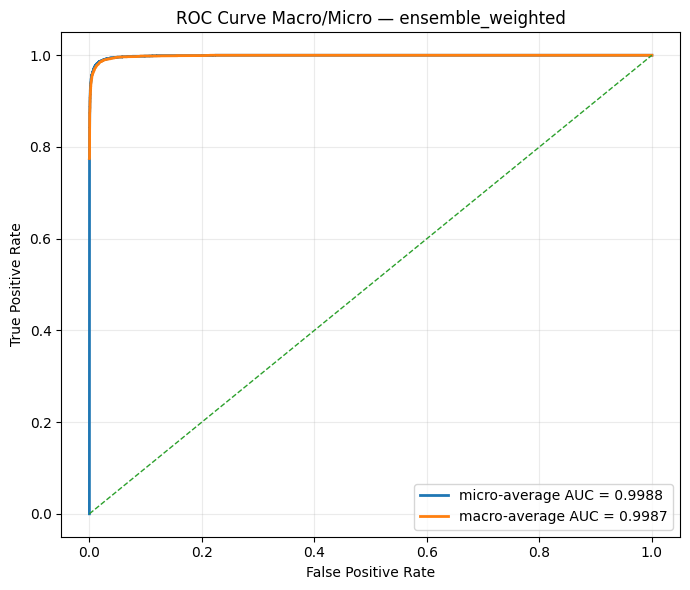

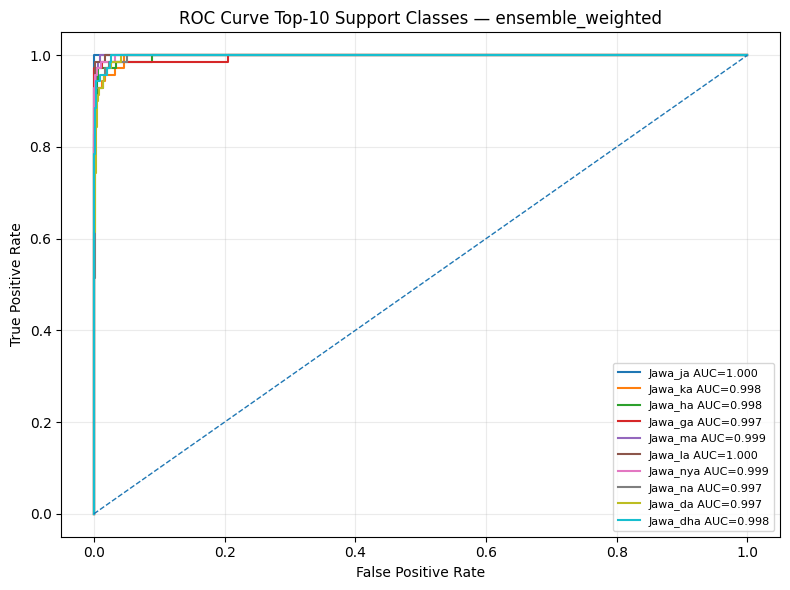

Saved ROC files:
 - /kaggle/working/aksara_output_improved/roc_auc_per_class.csv
 - /kaggle/working/aksara_output_improved/roc_auc_per_script.csv
 - /kaggle/working/aksara_output_improved/roc_auc_summary.csv
 - /kaggle/working/aksara_output_improved/roc_curve_macro_micro.png
 - /kaggle/working/aksara_output_improved/roc_curve_top_classes.png


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

if BEST_PROBA is None:
    print('BEST_PROBA kosong, ROC/AUC diskip. Pastikan best model punya predict_proba.')
else:
    proba = np.asarray(BEST_PROBA, dtype=np.float32)

    # Safety alignment: kolom proba harus sejumlah N_CLASSES.
    if proba.ndim != 2:
        raise RuntimeError(f'BEST_PROBA harus 2D, sekarang shape={proba.shape}')

    if proba.shape[1] != N_CLASSES:
        raise RuntimeError(f'Jumlah kolom proba ({proba.shape[1]}) != N_CLASSES ({N_CLASSES}). Cek alignment predict_proba.')

    labels_all = np.arange(N_CLASSES)
    y_bin = label_binarize(y_test, classes=labels_all)

    fpr = {}
    tpr = {}
    roc_auc = {}
    support = {}

    for i in labels_all:
        support_i = int((y_test == i).sum())
        support[int(i)] = support_i

        # ROC butuh positive dan negative sample. Kalau kelas tidak muncul di test, skip.
        if y_bin[:, i].sum() == 0 or y_bin[:, i].sum() == len(y_bin):
            roc_auc[int(i)] = np.nan
            continue

        fpr[int(i)], tpr[int(i)], _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc[int(i)] = auc(fpr[int(i)], tpr[int(i)])

    valid_classes = [i for i in labels_all if not np.isnan(roc_auc[int(i)])]

    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), proba.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)

    # Macro-average ROC manual dengan interpolasi.
    all_fpr = np.unique(np.concatenate([fpr[int(i)] for i in valid_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        mean_tpr += np.interp(all_fpr, fpr[int(i)], tpr[int(i)])
    mean_tpr /= max(1, len(valid_classes))
    auc_macro = auc(all_fpr, mean_tpr)

    # ROC AUC sklearn summary fallback/compare.
    try:
        auc_macro_sklearn = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
        auc_weighted_sklearn = roc_auc_score(y_bin, proba, average='weighted', multi_class='ovr')
    except Exception:
        auc_macro_sklearn = np.nan
        auc_weighted_sklearn = np.nan

    # Save per-class AUC.
    roc_rows = []
    for i in labels_all:
        cname = str(CLASS_NAMES[int(i)])
        script = cname.split('_')[0]
        character = cname.split('_', 1)[1] if '_' in cname else cname
        roc_rows.append({
            'label_id': int(i),
            'label': cname,
            'script': script,
            'character': character,
            'support': support[int(i)],
            'roc_auc_ovr': roc_auc[int(i)],
        })

    roc_class_df = pd.DataFrame(roc_rows)
    roc_class_path = OUTPUT_DIR / 'roc_auc_per_class.csv'
    roc_class_df.to_csv(roc_class_path, index=False)

    # Per-script AUC average.
    roc_script_df = (
        roc_class_df
        .dropna(subset=['roc_auc_ovr'])
        .groupby('script')
        .agg(
            n_classes=('label', 'count'),
            total_support=('support', 'sum'),
            mean_auc=('roc_auc_ovr', 'mean'),
            weighted_auc=('roc_auc_ovr', lambda s: np.average(s, weights=roc_class_df.loc[s.index, 'support']))
        )
        .reset_index()
    )
    roc_script_path = OUTPUT_DIR / 'roc_auc_per_script.csv'
    roc_script_df.to_csv(roc_script_path, index=False)

    # Summary CSV.
    roc_summary_df = pd.DataFrame([{
        'best_model_key': BEST_MODEL_KEY,
        'auc_micro_ovr': float(auc_micro),
        'auc_macro_ovr_manual': float(auc_macro),
        'auc_macro_ovr_sklearn': None if np.isnan(auc_macro_sklearn) else float(auc_macro_sklearn),
        'auc_weighted_ovr_sklearn': None if np.isnan(auc_weighted_sklearn) else float(auc_weighted_sklearn),
        'n_classes_total': int(N_CLASSES),
        'n_classes_valid_for_roc': int(len(valid_classes)),
        'test_samples': int(len(y_test)),
    }])
    roc_summary_path = OUTPUT_DIR / 'roc_auc_summary.csv'
    roc_summary_df.to_csv(roc_summary_path, index=False)

    print('ROC/AUC summary:')
    display(roc_summary_df)
    print('\nROC AUC per script:')
    display(roc_script_df)
    print('\nTop per-class ROC AUC:')
    display(roc_class_df.sort_values('roc_auc_ovr', ascending=False).head(10))
    print('\nLowest per-class ROC AUC:')
    display(roc_class_df.sort_values('roc_auc_ovr', ascending=True).head(10))

    # Plot macro + micro ROC.
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr_micro, tpr_micro, label=f'micro-average AUC = {auc_micro:.4f}', linewidth=2)
    ax.plot(all_fpr, mean_tpr, label=f'macro-average AUC = {auc_macro:.4f}', linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve Macro/Micro — {BEST_MODEL_KEY}')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    macro_micro_path = OUTPUT_DIR / 'roc_curve_macro_micro.png'
    plt.savefig(macro_micro_path, dpi=180)
    plt.show()

    # Plot top classes by support agar plot tidak terlalu ramai.
    top_classes = roc_class_df.dropna(subset=['roc_auc_ovr']).sort_values('support', ascending=False).head(10)['label_id'].astype(int).tolist()
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in top_classes:
        ax.plot(fpr[int(i)], tpr[int(i)], linewidth=1.5, label=f'{CLASS_NAMES[int(i)]} AUC={roc_auc[int(i)]:.3f}')
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve Top-10 Support Classes — {BEST_MODEL_KEY}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    top_path = OUTPUT_DIR / 'roc_curve_top_classes.png'
    plt.savefig(top_path, dpi=180)
    plt.show()

    print('Saved ROC files:')
    print(' -', roc_class_path)
    print(' -', roc_script_path)
    print(' -', roc_summary_path)
    print(' -', macro_micro_path)
    print(' -', top_path)

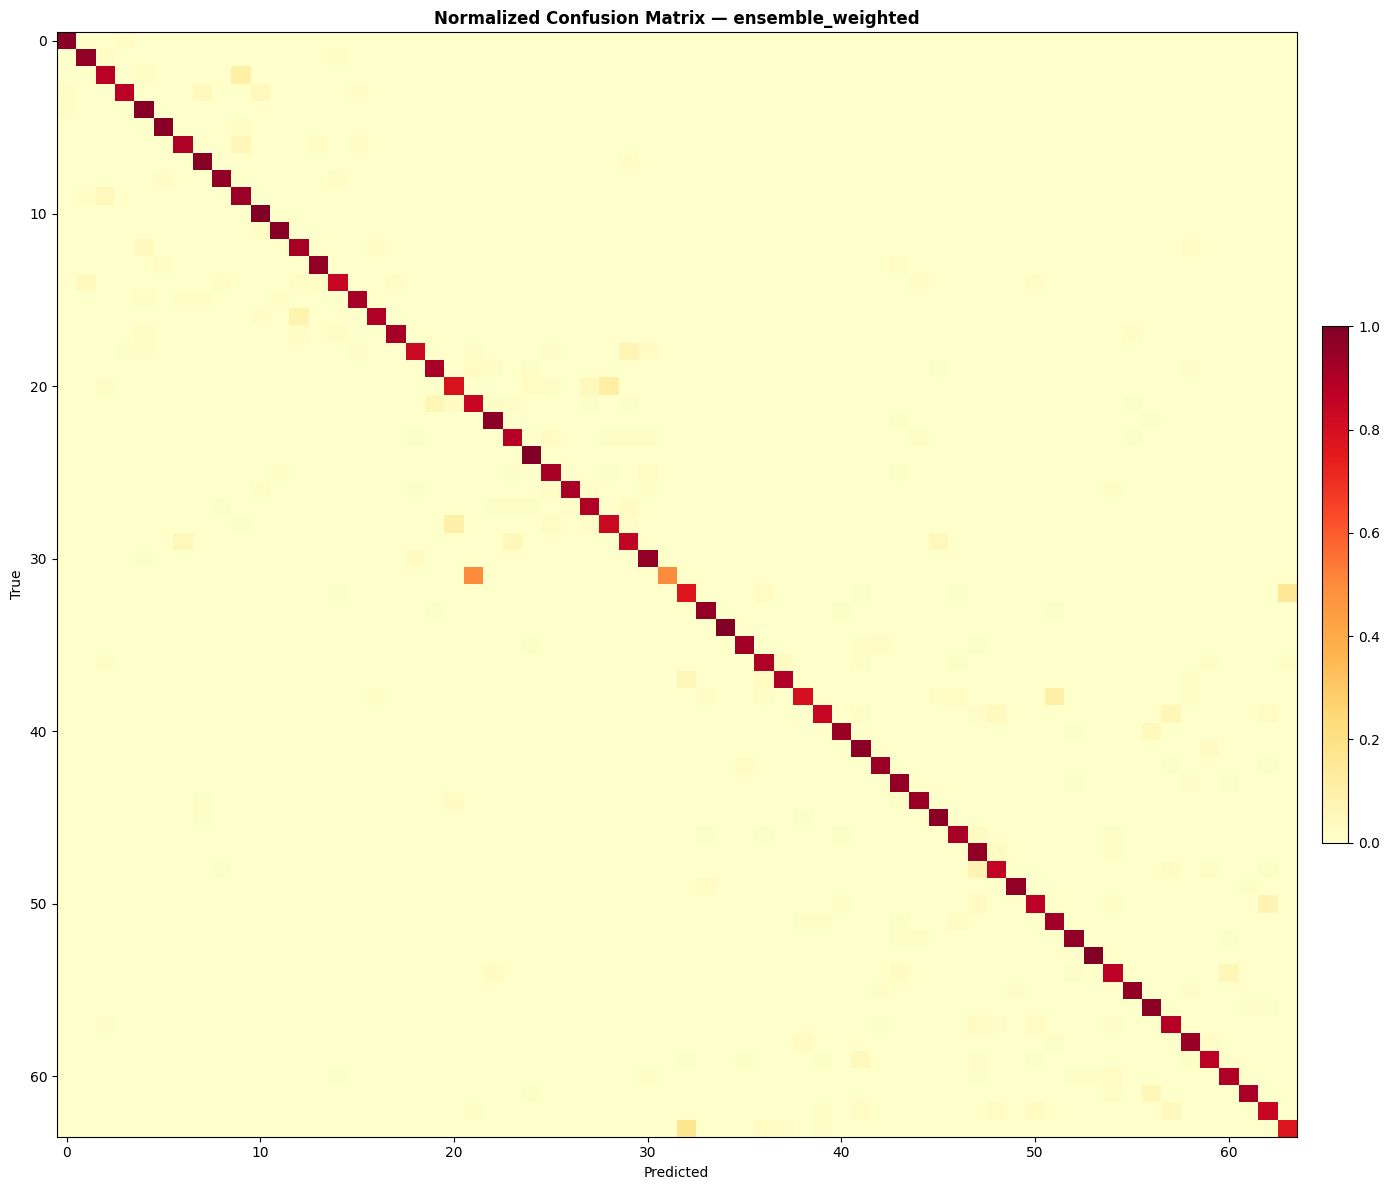

Saved -> /kaggle/working/aksara_output_improved/confusion_matrix.png


In [32]:
cm      = confusion_matrix(y_test, BEST_PRED)
cm_norm = cm.astype(float) / np.where(cm.sum(1, keepdims=True) == 0, 1, cm.sum(1, keepdims=True))

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
ax.set_title(f'Normalized Confusion Matrix — {BEST_MODEL_KEY}', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUTPUT_DIR}/confusion_matrix.png')

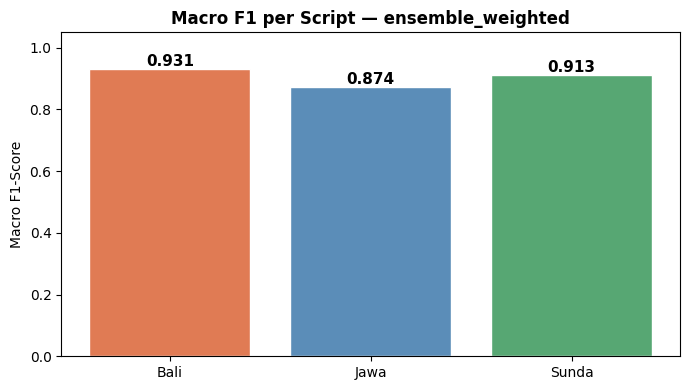

F1 per script:
  Bali    : 0.9313
  Jawa    : 0.8736
  Sunda   : 0.9127


In [33]:
rep = classification_report(
    y_test,
    BEST_PRED,
    labels=np.arange(len(CLASS_NAMES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

script_f1 = {}
for cname, metrics in rep.items():
    if not isinstance(metrics, dict):
        continue
    s = cname.split('_')[0]
    if s in SCRIPT_CONFIG:
        script_f1.setdefault(s, []).append(metrics['f1-score'])

script_avg = {s: np.mean(v) for s, v in script_f1.items()}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(script_avg.keys(), script_avg.values(),
              color=[COLORS.get(s, '#888') for s in script_avg], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1-Score')
ax.set_title(f'Macro F1 per Script — {BEST_MODEL_KEY}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'f1_per_script.png', dpi=120, bbox_inches='tight')
plt.show()

print('F1 per script:')
for s, v in script_avg.items():
    print(f'  {s:8s}: {v:.4f}')

# Debug Label Mapping, Confusion Pair, dan Ka vs Nya

In [ ]:
class_index_df = pd.DataFrame({
    'label_id': np.arange(N_CLASSES, dtype=int),
    'label': [str(x) for x in CLASS_NAMES],
})
class_index_df['script'] = class_index_df['label'].str.split('_').str[0]
class_index_df['character'] = class_index_df['label'].str.split('_', n=1).str[1]
class_index_df.to_csv(OUTPUT_DIR / 'class_index_mapping.csv', index=False)

print('Class mapping saved -> class_index_mapping.csv')
print(class_index_df.head(10).to_string(index=False))

print('\nClass order check:')
for key, model in TRAINED.items():
    if hasattr(model, 'classes_'):
        cls = np.asarray(model.classes_).astype(int)
        is_ordered = np.array_equal(cls, np.arange(len(cls)))
        print(f'  {key:18s}: classes ordered={is_ordered}, first={cls[:8]}')
    else:
        print(f'  {key:18s}: no classes_ attribute')

cm_raw = confusion_matrix(y_test, BEST_PRED, labels=np.arange(N_CLASSES))
rows = []
for true_i in range(N_CLASSES):
    total = cm_raw[true_i].sum()
    if total == 0:
        continue
    for pred_i in range(N_CLASSES):
        if true_i == pred_i:
            continue
        n = int(cm_raw[true_i, pred_i])
        if n > 0:
            rows.append({
                'true_id': int(true_i),
                'true_label': str(CLASS_NAMES[true_i]),
                'pred_id': int(pred_i),
                'pred_label': str(CLASS_NAMES[pred_i]),
                'count': n,
                'true_support': int(total),
                'error_rate_from_true': n / total,
            })

conf_pair_df = pd.DataFrame(rows)
if len(conf_pair_df):
    conf_pair_df = conf_pair_df.sort_values(['count', 'error_rate_from_true'], ascending=False).reset_index(drop=True)
    conf_pair_df.to_csv(OUTPUT_DIR / 'confusable_pairs.csv', index=False)
    print('\nTop confusable pairs:')
    display(conf_pair_df.head(20))
else:
    print('\nTidak ada confusion pair pada BEST_PRED.')

# 4) Fokus Bali_ka vs Bali_nya.
def _label_id(label_name):
    matches = np.where(np.asarray(CLASS_NAMES).astype(str) == label_name)[0]
    return int(matches[0]) if len(matches) else None

ka_id = _label_id('Bali_ka')
nya_id = _label_id('Bali_nya')
print('\nBali_ka index:', ka_id, '| Bali_nya index:', nya_id)

if ka_id is not None and nya_id is not None:
    for true_id, pred_id, title in [
        (ka_id, nya_id, 'Bali_ka -> Bali_nya'),
        (nya_id, ka_id, 'Bali_nya -> Bali_ka'),
    ]:
        mask = (y_test == true_id)
        if mask.sum() == 0:
            print(f'{title}: tidak ada sample test')
            continue
        wrong = int(np.sum(BEST_PRED[mask] == pred_id))
        correct = int(np.sum(BEST_PRED[mask] == true_id))
        print(f'{title}: support={int(mask.sum())}, correct={correct}, confused={wrong}, class_acc={correct / max(1, mask.sum()):.3f}')

    wrong_idx = np.where((y_test == ka_id) & (BEST_PRED == nya_id))[0]
    if len(wrong_idx) > 0:
        print(f'\nContoh Bali_ka yang diprediksi Bali_nya: {len(wrong_idx)} sample')
        n_show = min(8, len(wrong_idx))
        fig, axes = plt.subplots(1, n_show, figsize=(2*n_show, 2.3))
        if n_show == 1:
            axes = [axes]
        for ax, idx in zip(axes, wrong_idx[:n_show]):
            img = preprocess_image(X_paths_test[idx])
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            ax.set_title(f'true ka\npred nya', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print('\nTidak ada Bali_ka test yang salah menjadi Bali_nya pada BEST_MODEL_KEY.')

Class mapping saved -> class_index_mapping.csv
 label_id   label script character
        0 Bali_ba   Bali        ba
        1 Bali_ca   Bali        ca
        2 Bali_da   Bali        da
        3 Bali_ga   Bali        ga
        4 Bali_ha   Bali        ha
        5 Bali_ja   Bali        ja
        6 Bali_ka   Bali        ka
        7 Bali_la   Bali        la
        8 Bali_ma   Bali        ma
        9 Bali_na   Bali        na

Class order check:
  xgb               : classes ordered=True, first=[0 1 2 3 4 5 6 7]
  lgbm              : classes ordered=True, first=[0 1 2 3 4 5 6 7]
  cat               : classes ordered=True, first=[0 1 2 3 4 5 6 7]
  two_stage_lgbm    : classes ordered=True, first=[0 1 2 3 4 5 6 7]

Top confusable pairs:


,true_id,true_label,pred_id,pred_label,count,true_support,error_rate_from_true
0,63,Sunda_é,32,Sunda_a,12,70,0.171429
1,32,Sunda_a,63,Sunda_é,11,70,0.157143
2,20,Jawa_da,28,Jawa_na,8,70,0.114286
3,28,Jawa_na,20,Jawa_da,7,70,0.100000
4,38,Sunda_fa,51,Sunda_pa,7,70,0.100000
5,2,Bali_da,9,Bali_na,5,49,0.102041
6,18,Jawa_ba,29,Jawa_nga,5,70,0.071429
7,48,Sunda_nga,47,Sunda_na,5,70,0.071429
8,50,Sunda_o,62,Sunda_za,5,70,0.071429
9,16,Bali_wa,12,Bali_pa,4,50,0.080000



Bali_ka index: 6 | Bali_nya index: 11
Bali_ka -> Bali_nya: support=50, correct=45, confused=0, class_acc=0.900
Bali_nya -> Bali_ka: support=50, correct=49, confused=0, class_acc=0.980

Tidak ada Bali_ka test yang salah menjadi Bali_nya pada BEST_MODEL_KEY.


# Inference Latency (Target < 100 ms)

In [35]:
_ext_bench  = FeatureExtractor()
_samp_path  = df['filepath'].iloc[0]
_samp_img   = preprocess_image(_samp_path)
N_BENCH     = 100

def _single_inference(img, model_key):
    feat   = _ext_bench.extract(img)
    feat_s = scaler.transform(feat.reshape(1, -1))
    feat_p = pca.transform(feat_s)

    if model_key in ['ensemble_equal', 'ensemble_weighted']:
        if model_key == 'ensemble_weighted' and 'ENSEMBLE_KEYS' in globals() and ENSEMBLE_WEIGHTS is not None:
            p, _, _ = _average_predict_proba(feat_p, ENSEMBLE_KEYS, ENSEMBLE_WEIGHTS)
        else:
            p, _, _ = _average_predict_proba(feat_p, [k for k in TRAINED if PROBAS.get(k) is not None])
        return int(np.argmax(p))

    pred = TRAINED[model_key].predict(feat_p)
    return int(np.asarray(pred).reshape(-1)[0])

bench_keys = list(TRAINED.keys())
for ens_key in ['ensemble_equal', 'ensemble_weighted']:
    if ens_key in PREDS:
        bench_keys.append(ens_key)

print('Benchmark model:', bench_keys)

for k in bench_keys:
    for _ in range(5):
        _single_inference(_samp_img, k)

    t0 = time.time()

    for _ in range(N_BENCH):
        _single_inference(_samp_img, k)

    lat = (time.time() - t0) / N_BENCH * 1000
    status = 'PASS' if lat < 100 else 'FAIL'
    print(f'  {k:20s}: {lat:6.2f} ms  [{status}]')

Benchmark model: ['xgb', 'lgbm', 'cat', 'two_stage_lgbm', 'ensemble_equal', 'ensemble_weighted']
  xgb                 : 182.92 ms  [FAIL]
  lgbm                : 138.00 ms  [FAIL]
  cat                 : 120.84 ms  [FAIL]
  two_stage_lgbm      : 169.35 ms  [FAIL]
  ensemble_equal      : 249.49 ms  [FAIL]
  ensemble_weighted   : 186.30 ms  [FAIL]


# Simpan File 

In [43]:
import json as _json

# Save dynamic ensemble model
joblib.dump(ensemble_model, OUTPUT_DIR / 'stacking_model.pkl')

# Save guarded deployment model + specialist models
if 'guarded_model' in globals():
    joblib.dump(guarded_model, OUTPUT_DIR / 'guarded_model.pkl')
    print('Saved guarded model: guarded_model.pkl')

if 'specialist_models' in globals():
    joblib.dump(specialist_models, OUTPUT_DIR / 'specialist_models.pkl')
    print('Saved specialist models: specialist_models.pkl')

# Save all trained individual models
for key, model in TRAINED.items():
    path = OUTPUT_DIR / f'{key}_model.pkl'
    joblib.dump(model, path)
    print(f'Saved model: {path.name}')

best_row = results_df.iloc[0].to_dict()

cfg = {
    'run_preset': str(RUN_PRESET),
    'n_trials': int(N_TRIALS),
    'tune_frac': float(TUNE_FRAC),
    'tuning_timeout_seconds': int(TUNING_TIMEOUT_SECONDS),
    'best_model_name': str(best_row['Model']),
    'best_model_key': str(best_row['Key']),
    'macro_f1': round(float(best_row['Macro F1']), 6),
    'accuracy': round(float(best_row['Accuracy']), 6),
    'val_macro_f1': None if pd.isna(best_row.get('Val Macro F1', np.nan)) else round(float(best_row.get('Val Macro F1')), 6),
    'n_classes': int(N_CLASSES),
    'scripts': list(SCRIPT_CONFIG.keys()),
    'img_size': int(IMG_SIZE),
    'feat_dim_raw': int(FEAT_DIM),
    'feat_dim_pca': int(PCA_DIM),
    'pca_variance': float(PCA_VARIANCE),
    'feature_version': str(FEATURE_VERSION),
    'augment_train': bool(AUGMENT_TRAIN),
    'aug_target_per_class': int(AUG_TARGET_PER_CLASS),
    'models_trained': list(TRAINED.keys()),
    'models_in_ensemble': list(_ensemble_keys_for_app),
    'ensemble_weights': None if _ensemble_weights_for_app is None else [float(x) for x in _ensemble_weights_for_app],
    'guardrails': {
        'conf_threshold': float(globals().get('CONF_THRESHOLD', 0.45)),
        'margin_threshold': float(globals().get('MARGIN_THRESHOLD', 0.08)),
        'multi_object_reject': bool(globals().get('MULTI_OBJECT_REJECT', True)),
        'large_component_area_ratio': float(globals().get('LARGE_COMPONENT_AREA_RATIO', 0.04)),
        'max_large_components': int(globals().get('MAX_LARGE_COMPONENTS', 1)),
        'specialist_pairs': [(str(CLASS_NAMES[a]), str(CLASS_NAMES[b])) for (a, b) in globals().get('specialist_pair_ids', [])],
    },
    'per_script_f1': {s: round(float(v), 4) for s, v in script_avg.items()} if 'script_avg' in globals() else {},
}

with open(OUTPUT_DIR / 'inference_config.json', 'w') as f:
    _json.dump(cfg, f, indent=2)

joblib.dump(results_df, OUTPUT_DIR / 'results_df.pkl')

print(f'Artifacts tersimpan di: {OUTPUT_DIR}')
print()

for p in sorted(OUTPUT_DIR.glob('*.pkl')) + sorted(OUTPUT_DIR.glob('*.json')):
    print(f'  {p.name:45s}  {p.stat().st_size/1024:.1f} KB')

# ============================================================
# ZIP OUTPUT MODEL / DEPLOYMENT ARTIFACTS
# ============================================================
import zipfile

ZIP_PATH = OUTPUT_DIR.parent / f'{OUTPUT_DIR.name}_model_artifacts.zip'

include_exts = {'.pkl', '.json', '.npy', '.csv', '.png', '.txt', '.py', '.md'}
exclude_dirs = {'features', '__pycache__'}

zipped_files = []

with zipfile.ZipFile(ZIP_PATH, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in sorted(OUTPUT_DIR.rglob('*')):
        if not file_path.is_file():
            continue

        rel_parts = set(file_path.relative_to(OUTPUT_DIR).parts)
        if rel_parts & exclude_dirs:
            continue

        if file_path.suffix.lower() not in include_exts:
            continue

        arcname = Path(OUTPUT_DIR.name) / file_path.relative_to(OUTPUT_DIR)
        zf.write(file_path, arcname=arcname)
        zipped_files.append(file_path)

manifest_path = OUTPUT_DIR / 'zip_manifest.txt'
with open(manifest_path, 'w') as f:
    f.write('Nusantara Script Recognition - Improved Classical ML Model Artifacts\n')
    f.write(f'Output dir: {OUTPUT_DIR}\n')
    f.write(f'Zip path  : {ZIP_PATH}\n')
    f.write(f'Feature version: {FEATURE_VERSION}\n\n')
    f.write('Included files:\n')
    for fp in zipped_files:
        f.write(f'- {fp.relative_to(OUTPUT_DIR)} ({fp.stat().st_size/1024:.1f} KB)\n')

with zipfile.ZipFile(ZIP_PATH, 'a', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(manifest_path, arcname=Path(OUTPUT_DIR.name) / manifest_path.name)

print('\nZIP artifact berhasil dibuat:')
print(f'  {ZIP_PATH}')
print(f'  Size: {ZIP_PATH.stat().st_size / (1024*1024):.2f} MB')
print('\nIsi utama ZIP:')
for fp in zipped_files[:30]:
    print(f'  - {fp.relative_to(OUTPUT_DIR)}')

if len(zipped_files) > 30:
    print(f'  ... dan {len(zipped_files) - 30} file lainnya')


Saved guarded model: guarded_model.pkl
Saved specialist models: specialist_models.pkl
Saved model: xgb_model.pkl
Saved model: lgbm_model.pkl
Saved model: cat_model.pkl
Saved model: two_stage_lgbm_model.pkl
Artifacts tersimpan di: /kaggle/working/aksara_output_improved

  best_params.pkl                                0.4 KB
  cat_model.pkl                                  41423.8 KB
  class_weights.pkl                              0.7 KB
  guarded_model.pkl                              198172.8 KB
  label_encoder.pkl                              1.1 KB
  lgbm_model.pkl                                 21389.9 KB
  pca_model.pkl                                  61855.6 KB
  pca_model_v5_kaggle_t4x2_balance_img96_pca98_aug250_stroke_guarded_final.pkl  61855.6 KB
  predictions.pkl                                188.1 KB
  probabilities.pkl                              6002.1 KB
  results_df.pkl                                 1.6 KB
  scaler.pkl                                     150.2 KB

# Ringkasan Hasil

In [41]:
print('=' * 70)
print('  NUSANTARA SCRIPT RECOGNITION — IMPROVED CLASSICAL ML SUMMARY')
print('=' * 70)
print(f'  Script         : {list(SCRIPT_CONFIG.keys())}')
print(f'  Total kelas    : {N_CLASSES}')
print(f'  Train samples  : {len(y_train):,}  (cap={MAX_PER_CLASS}/kelas, augment={AUGMENT_TRAIN})')
print(f'  Test samples   : {len(y_test):,}')
print(f'  Feature dim    : {FEAT_DIM}D -> PCA -> {PCA_DIM}D')
print(f'  Feature version: {FEATURE_VERSION}')
print()
print('  LEADERBOARD:')
print(results_df.to_string(index=False))
print()
print('  F1 per script:')
for s, v in script_avg.items():
    print(f'    {s:8s}: {v:.4f}')
print()
print('  NOTE:')
print('    Target 80% tidak dijamin mutlak, tapi pipeline ini sudah memakai preprocessing,')
print('    fitur stroke, train-only augmentation, two-stage model, dan weighted ensemble.')
print()
print('  DEPLOYMENT:')
print('    file app.py + requirements.txt sudah masuk ke ZIP artifact')
print('    setelah download: pip install -r requirements.txt && streamlit run app.py')
print('=' * 70)
print()
if 'ZIP_PATH' in globals():
    print(f'  ZIP artifact   : {ZIP_PATH}')
    print('    download file .zip ini untuk simpan/share output model')

  NUSANTARA SCRIPT RECOGNITION — IMPROVED CLASSICAL ML SUMMARY
  Script         : ['Bali', 'Jawa', 'Sunda']
  Total kelas    : 64
  Train samples  : 15,774  (cap=350/kelas, augment=True)
  Test samples   : 4,001
  Feature dim    : 6382D -> PCA -> 2479D
  Feature version: v5_kaggle_t4x2_balance_img96_pca98_aug250_stroke_guarded_final

  LEADERBOARD:
                                       Model               Key  Accuracy  Macro F1  Val Macro F1 Waktu (s)
 Weighted SoftVote (lgbm+cat+two_stage_lgbm) ensemble_weighted  0.914021  0.909391      0.909563       N/A
Equal SoftVote (xgb+lgbm+cat+two_stage_lgbm)    ensemble_equal  0.912272  0.908332           NaN       N/A
                                     XGBoost               xgb  0.898525  0.895240      0.889782     334.3
                           TwoStage LightGBM    two_stage_lgbm  0.896276  0.893169      0.889501    1863.8
                                    LightGBM              lgbm  0.891527  0.887772      0.882083    1264.7
       

# Cek Overfit / Underfit

In [42]:
# cek overfitt
def eval_split(name, X, y, model):
    pred = model.predict(X)
    pred = np.asarray(pred).reshape(-1).astype(int)

    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred, average='macro', zero_division=0)

    print(f'{name:10s} | Acc={acc:.4f} | Macro-F1={f1:.4f}')


print("=== Overfit Check ===")

best_eval_model = guarded_model if 'guarded_model' in globals() else ensemble_model

eval_split("Train/Fit", X_fit, y_fit, best_eval_model)
eval_split("Valid", X_val, y_val, best_eval_model)
eval_split("Test", X_test, y_test, best_eval_model)

=== Overfit Check ===
Train/Fit  | Acc=1.0000 | Macro-F1=1.0000
Valid      | Acc=0.9225 | Macro-F1=0.9090
Test       | Acc=0.9140 | Macro-F1=0.9094


In [ ]:
def print_overfit_verdict(train_acc, train_f1, valid_acc, valid_f1, test_acc, test_f1):
    gap_train_valid_f1 = train_f1 - valid_f1
    gap_train_test_f1  = train_f1 - test_f1
    gap_valid_test_f1  = abs(valid_f1 - test_f1)

    gap_train_valid_acc = train_acc - valid_acc
    gap_train_test_acc  = train_acc - test_acc
    gap_valid_test_acc  = abs(valid_acc - test_acc)

    print("=" * 70)
    print("OVERFIT ANALYSIS")
    print("=" * 70)

    print(f"Train Acc      : {train_acc:.4f}")
    print(f"Valid Acc      : {valid_acc:.4f}")
    print(f"Test Acc       : {test_acc:.4f}")
    print(f"Gap Train-Test Acc : {gap_train_test_acc:.4f}")
    print()

    print(f"Train Macro-F1 : {train_f1:.4f}")
    print(f"Valid Macro-F1 : {valid_f1:.4f}")
    print(f"Test Macro-F1  : {test_f1:.4f}")
    print(f"Gap Train-Valid F1 : {gap_train_valid_f1:.4f}")
    print(f"Gap Train-Test F1  : {gap_train_test_f1:.4f}")
    print(f"Gap Valid-Test F1  : {gap_valid_test_f1:.4f}")
    print()

    # Rule sederhana
    if train_f1 >= 0.99 and gap_train_test_f1 >= 0.15:
        verdict = "OVERFIT BERAT"
        note = "Train hampir sempurna, tapi performa test turun jauh."
    elif train_f1 >= 0.99 and gap_train_test_f1 >= 0.07:
        verdict = "OVERFIT RINGAN / SEDANG"
        note = "Train perfect, tapi test masih cukup tinggi. Model agak memorisasi, tapi generalisasi masih oke."
    elif gap_train_test_f1 < 0.07 and gap_valid_test_f1 < 0.03:
        verdict = "AMAN / GENERALISASI BAGUS"
        note = "Gap train-test kecil dan valid-test stabil."
    else:
        verdict = "PERLU DICEK LANJUT"
        note = "Ada gap yang perlu dicek lewat confusion matrix dan user testing."

    print(f"Verdict: {verdict}")
    print(f"Catatan: {note}")

    if gap_valid_test_f1 <= 0.02:
        print("Valid-Test Stability: BAGUS, performa valid dan test konsisten.")
    elif gap_valid_test_f1 <= 0.05:
        print("Valid-Test Stability: MASIH OKE, ada sedikit perbedaan.")
    else:
        print("Valid-Test Stability: KURANG STABIL, kemungkinan split/domain berbeda.")

    print("=" * 70)

print_overfit_verdict(
    train_acc=1.0000,
    train_f1=1.0000,
    valid_acc=0.9225,
    valid_f1=0.9090,
    test_acc=0.9140,
    test_f1=0.9094
)

OVERFIT ANALYSIS
Train Acc      : 1.0000
Valid Acc      : 0.9225
Test Acc       : 0.9140
Gap Train-Test Acc : 0.0860

Train Macro-F1 : 1.0000
Valid Macro-F1 : 0.9090
Test Macro-F1  : 0.9094
Gap Train-Valid F1 : 0.0910
Gap Train-Test F1  : 0.0906
Gap Valid-Test F1  : 0.0004

Verdict: OVERFIT RINGAN / SEDANG
Catatan: Train perfect, tapi test masih cukup tinggi. Model agak memorisasi, tapi generalisasi masih oke.
Valid-Test Stability: BAGUS, performa valid dan test konsisten.
